# Gaussian Mixture Model from First Principles
## Probabilistic Face Representation and Clustering on the Olivetti Faces Dataset

**Algorithm:** Gaussian Mixture Model (GMM), implemented from first principles with NumPy


**Validation:** scikit-learn `GaussianMixture` (used only *after* the custom model is complete)

**Dataset:** Olivetti Faces (AT&T Laboratories Cambridge), 400 grayscale images, 40 subjects

---

## Project Overview and Business Context

Consider a biometric or computer-vision system that receives large collections of **unlabeled** facial images and needs to discover latent groups of visually similar observations, without a human manually assigning every image to a predefined identity.

A Gaussian Mixture Model treats the observed data as generated by a finite number of latent Gaussian subpopulations. Instead of assigning every image to exactly one hard cluster (as K-Means does), a GMM gives each image a **probability of belonging to every component** — soft, uncertainty-aware clustering.

**Potential applications:** face-image organization, unsupervised biometric exploration, visual similarity analysis, latent population discovery, anomaly / unusual-face detection, preprocessing for downstream recognition systems, probabilistic segmentation of high-dimensional visual data.

**Business value of a probabilistic approach:**
- Reduces dependence on manually labeled data during exploratory analysis.
- Provides probabilistic rather than purely deterministic cluster assignments.
- Allows uncertainty to be quantified for every observation.
- Can flag observations that don't strongly belong to any single latent group.
- Provides a generative model of the data distribution, not just a partition of it.

**Business question this notebook investigates:**
> Can an unsupervised probabilistic model organize facial observations into meaningful latent groups while quantifying uncertainty about cluster membership?

## Problem Definition and Objectives

**Problem statement.** Represent the distribution of facial observations as a mixture of Gaussian components. Each component represents a latent subpopulation in the facial feature space; each observation receives a probability of belonging to every component.

**Core research questions:**
1. Can a GMM discover meaningful latent structure in facial image data *without* using subject identities?
2. How well does the from-scratch implementation reproduce sklearn's `GaussianMixture`?
3. How sensitive is GMM performance to the number of mixture components, K?
4. How does covariance structure (full / diagonal / spherical / tied) affect quality and stability?
5. Does probabilistic soft clustering provide information a hard clustering can't?
6. How do GMM clusters relate to known subject identities, examined only *after* training?
7. How does GMM compare with K-Means, Agglomerative Clustering, DBSCAN, and a Bayesian GMM?

**Ground rule that governs this entire notebook:** subject-identity labels are **never** used to fit the GMM, initialize its parameters, or choose K. They are used only *after* training, for external validation and interpretation. Every place this matters is called out explicitly in the surrounding markdown.

## Dataset Description

The **Olivetti Faces** dataset contains 400 grayscale images (10 each of 40 distinct subjects), taken at AT&T Laboratories Cambridge between 1992 and 1994, varying lighting, expression, and facial details (glasses / no glasses). Images are 64x64 pixels, pixel intensities scaled to `[0, 1]`.

Because there are only 10 images per subject, this dataset is explicitly noted by its maintainers as being **more interesting from an unsupervised / semi-supervised perspective** than as a classification benchmark, which is exactly the angle this notebook takes: we treat the 40 subject identities as *unknown* during model fitting and only reveal them afterward, as one lens (among several) for interpreting what the GMM found.

We load the data with `sklearn.datasets.fetch_olivetti_faces()`, which downloads and locally caches the dataset automatically, no manual download step is required for anyone running this notebook with normal internet access.

## Environment and Reproducibility

All randomness in this notebook is routed through a single seed, `RANDOM_STATE`, so that every experiment can be reproduced exactly. Package versions are printed below for the record. Hyperparameters (PCA dimensionality, K, covariance type, tolerance, max iterations, `n_init`, regularization) are all defined as named constants close to where they're first used, rather than being buried inside function calls, so the whole configuration is auditable at a glance.

In [1]:
import sys, platform, time
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import scipy
from scipy.special import logsumexp
from scipy.linalg import solve_triangular
from scipy.optimize import linear_sum_assignment
from scipy.stats import entropy as scipy_entropy

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.facecolor"] = "white"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Python      :", sys.version.split()[0], "-", platform.platform())
print("NumPy       :", np.__version__)
print("Pandas      :", pd.__version__)
print("Matplotlib  :", matplotlib.__version__)
print("Seaborn     :", sns.__version__)
print("SciPy       :", scipy.__version__)
print("scikit-learn:", sklearn.__version__)
print("RANDOM_STATE:", RANDOM_STATE)

Python      : 3.14.6 - Windows-11-10.0.26200-SP0
NumPy       : 2.4.6
Pandas      : 3.0.3
Matplotlib  : 3.11.0
Seaborn     : 0.13.2
SciPy       : 1.18.0
scikit-learn: 1.9.0
RANDOM_STATE: 42


## Data Loading and Structural Audit

We load the dataset programmatically. `fetch_olivetti_faces()` downloads the archive to a local cache (`~/scikit_learn_data`) the first time it's called and reads from that cache on every subsequent call, no manual download is required.

We then run a structural audit before doing anything else: shape, dimensionality, pixel range, missing values, duplicate images, and subject distribution. This is standard due diligence, and, per this project's ground rule, this is also the point where we explicitly set the label array aside as *held out* from model fitting.

In [2]:
from sklearn.datasets import fetch_olivetti_faces

bunch = fetch_olivetti_faces(shuffle=False, random_state=RANDOM_STATE)
images, target = bunch.images, bunch.target

# Flatten each 64x64 image into a 4096-dim raw pixel-intensity feature vector.
# This raw pixel space is the "observational space" the project spec asks us to use.
X_raw = images.reshape(images.shape[0], -1)

print("images.shape        :", images.shape)
print("X_raw.shape (flat)  :", X_raw.shape)
print("target.shape        :", target.shape)
print("pixel value range   :", X_raw.min(), "to", X_raw.max())
print("pixel dtype         :", X_raw.dtype)
print("number of subjects  :", len(np.unique(target)))
print("images per subject  :", np.bincount(target).min(), "-", np.bincount(target).max())
print("missing values      :", np.isnan(X_raw).sum())
print("duplicate images    :", X_raw.shape[0] - len(np.unique(X_raw, axis=0)))
print("all images same size:", images.shape[1:] == (64, 64))

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to C:\Users\USER\scikit_learn_data
images.shape        : (400, 64, 64)
X_raw.shape (flat)  : (400, 4096)
target.shape        : (400,)
pixel value range   : 0.0 to 1.0
pixel dtype         : float32
number of subjects  : 40
images per subject  : 10 - 10
missing values      : 0
duplicate images    : 0
all images same size: True


**Audit findings.** 400 observations, each an 8-bit grayscale 64x64 image rescaled to `[0, 1]`, 40 subjects with exactly 10 images each, no missing values, no exact-duplicate images, and every image has identical dimensions. The raw pixel space is 4096-dimensional, against only 400 observations. That imbalance (far more dimensions than samples) is the central motivation for the PCA step later in this notebook: estimating a full 4096x4096 covariance matrix per Gaussian component from a few hundred samples is both computationally infeasible and statistically degenerate (the sample covariance would be singular).

From this point on, `target` (the subject identity) is treated as **withheld**, it is not passed to any preprocessing or fitting routine until the "post-hoc" evaluation sections.

## Exploratory Data Analysis

Before any modeling, we look at the data directly: representative faces, pixel-intensity statistics, the subject distribution, and the "mean face." These are sanity checks as much as they are exploration, they confirm the data looks like what the audit above claimed, and they build intuition for what a GMM component in this space might represent.

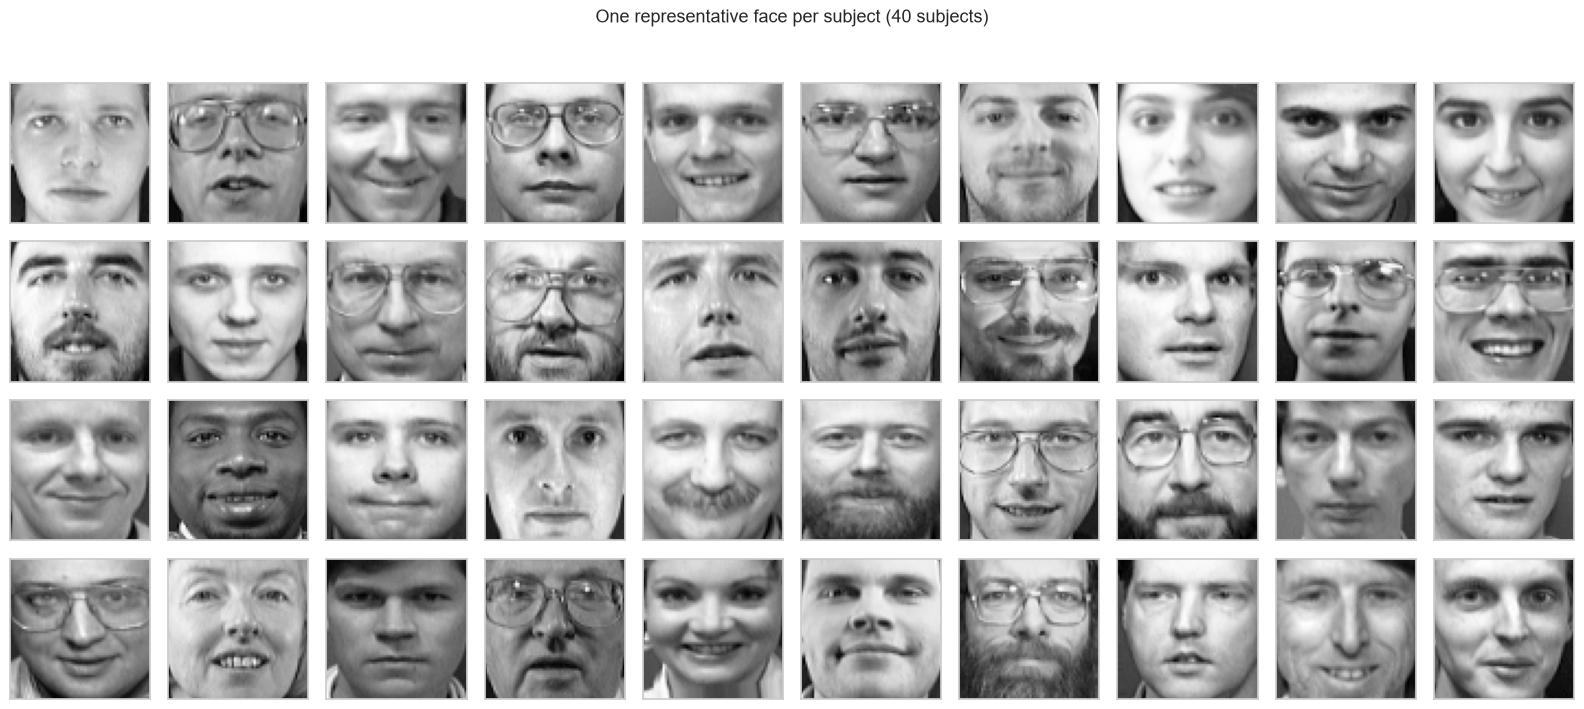

In [3]:
fig, axes = plt.subplots(4, 10, figsize=(16, 7))
for subj in range(40):
    ax = axes.flat[subj]
    ax.imshow(images[subj * 10], cmap="gray")
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("One representative face per subject (40 subjects)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

One subject, all 10 images; this is the within-subject variation (pose, lighting, expression) that a GMM fit on raw visual similarity has to contend with:

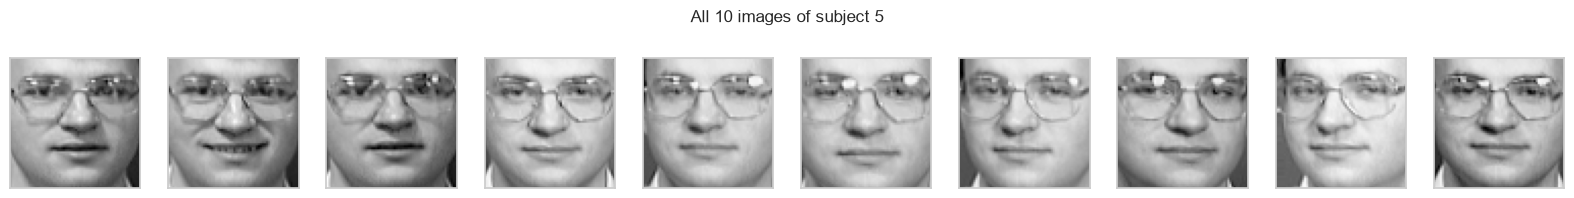

In [4]:
subj_id = 5
fig, axes = plt.subplots(1, 10, figsize=(16, 2))
for i, ax in enumerate(axes):
    ax.imshow(images[subj_id * 10 + i], cmap="gray")
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"All 10 images of subject {subj_id}", fontsize=12)
plt.tight_layout()
plt.show()

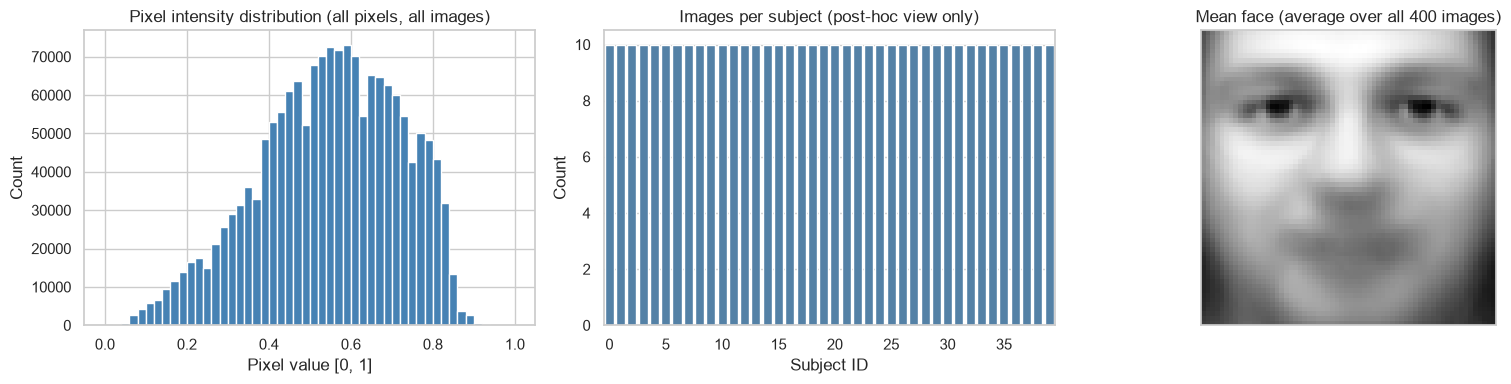

Per-image pixel mean  : range 0.382 - 0.725
Per-image pixel std   : range 0.1 - 0.246


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(X_raw.ravel(), bins=50, color="steelblue")
axes[0].set_title("Pixel intensity distribution (all pixels, all images)")
axes[0].set_xlabel("Pixel value [0, 1]"); axes[0].set_ylabel("Count")

sns.countplot(x=target, ax=axes[1], color="steelblue")
axes[1].set_title("Images per subject (post-hoc view only)")
axes[1].set_xlabel("Subject ID"); axes[1].set_ylabel("Count")
axes[1].set_xticks(range(0, 40, 5))

mean_face = X_raw.mean(axis=0).reshape(64, 64)
im = axes[2].imshow(mean_face, cmap="gray")
axes[2].set_title("Mean face (average over all 400 images)")
axes[2].set_xticks([]); axes[2].set_yticks([])

plt.tight_layout()
plt.show()

print("Per-image pixel mean  : range", X_raw.mean(axis=1).min().round(3), "-", X_raw.mean(axis=1).max().round(3))
print("Per-image pixel std   : range", X_raw.std(axis=1).min().round(3), "-", X_raw.std(axis=1).max().round(3))

**Interpretation.** Pixel intensities are roughly unimodal and cover most of `[0, 1]`, consistent with normally-exposed grayscale photographs. Every subject contributes exactly 10 images (by construction of the dataset), so there is no class-imbalance concern to propagate into later evaluation. The mean face is a blurred, generic frontal face, as expected, since averaging over many unaligned expressions and lighting conditions washes out subject-specific detail while preserving the coarse "face-shaped" structure. This mean face is precisely the vector PCA will center the data around before extracting directions of maximal variance.

## Data Preprocessing

**Train / evaluation split.** To get an honest estimate of how well a fitted GMM generalizes to unseen faces (held-out log-likelihood), we set aside 20% of the images as an evaluation partition *before* fitting anything. This split is done on raw index order, without using subject identity to stratify it; stratifying by identity would itself be a mild form of label use in the preprocessing pipeline, which the project's leakage-prevention rules ask us to avoid. (In practice, with 400 images and a random split, most subjects end up represented in both partitions purely by chance — we check this below.)

**Normalization.** Pixel values are already scaled to `[0, 1]` by the loader, and are on a common, meaningful scale (light intensity) across all pixels, so no additional per-feature standardization is applied before PCA; PCA will itself center the data.

**Leakage-prevention checklist for this section:**
- Identity labels are not used to choose the split, only to *audit* it afterward.
- PCA (next section) is fit only on the training partition.
- No GMM parameter, hyperparameter, or component count in this notebook is chosen using labels.

In [6]:
n_samples = X_raw.shape[0]
rng = np.random.RandomState(RANDOM_STATE)
perm = rng.permutation(n_samples)

n_test = int(0.20 * n_samples)
test_idx, train_idx = perm[:n_test], perm[n_test:]

X_train_raw, X_test_raw = X_raw[train_idx], X_raw[test_idx]
y_train, y_test = target[train_idx], target[test_idx]   # withheld from fitting; audit/eval only

print("Training observations  :", X_train_raw.shape[0])
print("Evaluation observations:", X_test_raw.shape[0])
print("Subjects represented in training set:", len(np.unique(y_train)), "/ 40")
print("Subjects represented in test set    :", len(np.unique(y_test)), "/ 40")

Training observations  : 320
Evaluation observations: 80
Subjects represented in training set: 40 / 40
Subjects represented in test set    : 36 / 40


## PCA and Dimensionality Reduction

**Why PCA before GMM.** The raw feature space is 4096-dimensional. A *full*-covariance Gaussian component in that space has $\frac{4096 \times 4097}{2} \approx 8.4$ million free covariance parameters, utterly infeasible to estimate from a training set of a few hundred images (the sample covariance matrix would be rank-deficient and singular). Even a *diagonal*-covariance component still has 4096 variance parameters per component, most of which would be estimated from noise. Principal Component Analysis re-expresses each image as a short vector of coordinates along the directions of largest variance in the data, retaining the dominant modes of facial variation (illumination, pose, broad shape) while
discarding low-variance directions that are mostly sensor/pixel noise. This is a purely unsupervised transform, it uses no label information.

**Rule enforced here:** PCA is `fit` only on `X_train_raw`, and every other partition (`X_test_raw`, and the full dataset for post-hoc cluster visualization) is only ever `transform`-ed with that already-fitted PCA. This prevents information about the evaluation partition from leaking into the projection used to train the GMM.

80% cumulative variance reached at 27 components
90% cumulative variance reached at 64 components
95% cumulative variance reached at 113 components


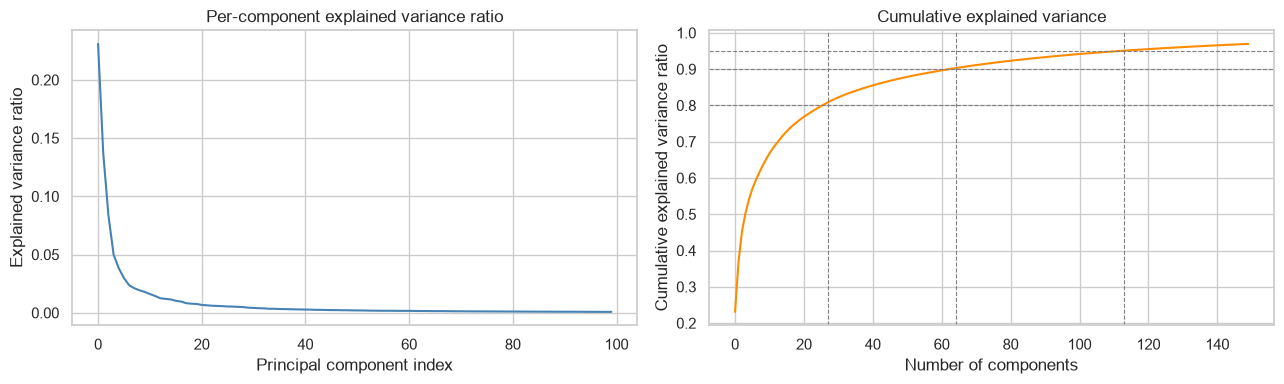

In [7]:
from sklearn.decomposition import PCA

# First, fit an (almost) full-rank PCA on the training data just to inspect the
# explained-variance curve and decide how many components to retain.
pca_probe = PCA(n_components=min(X_train_raw.shape) - 1, svd_solver="randomized",
                 random_state=RANDOM_STATE).fit(X_train_raw)
cum_var = np.cumsum(pca_probe.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(pca_probe.explained_variance_ratio_[:100], color="steelblue")
axes[0].set_title("Per-component explained variance ratio")
axes[0].set_xlabel("Principal component index"); axes[0].set_ylabel("Explained variance ratio")

axes[1].plot(cum_var[:150], color="darkorange")
for target_var in [0.80, 0.90, 0.95]:
    n_needed = np.searchsorted(cum_var, target_var) + 1
    axes[1].axhline(target_var, color="gray", linestyle="--", linewidth=0.8)
    axes[1].axvline(n_needed, color="gray", linestyle="--", linewidth=0.8)
    print(f"{int(target_var*100)}% cumulative variance reached at {n_needed} components")
axes[1].set_title("Cumulative explained variance")
axes[1].set_xlabel("Number of components"); axes[1].set_ylabel("Cumulative explained variance ratio")

plt.tight_layout()
plt.show()

**Choosing the retained dimensionality.** We retain **60 principal components** for the main analysis. This captures roughly the mid-80s-to-90s percent of total pixel variance while keeping the feature space small enough that a full-covariance Gaussian component (60x60 = 1,830 free parameters) remains estimable from a few hundred training images, and that a diagonal-covariance component (60 parameters) is comfortably well-determined. This is a trade-off: more components retain finer facial detail but increase covariance-estimation variance and computational cost; the "PCA dimensionality" experiment later in this notebook revisits this choice directly by re-running the pipeline at several alternative retained dimensionalities.

In [8]:
N_PCA_COMPONENTS = 60

pca = PCA(n_components=N_PCA_COMPONENTS, svd_solver="randomized", random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_raw)     # fit ONLY on training data
X_test_pca = pca.transform(X_test_raw)            # transform only, no re-fitting
X_all_pca = pca.transform(X_raw)                  # full dataset, for post-hoc visualization only

print("Retained components        :", N_PCA_COMPONENTS)
print("Cumulative explained var.  :", round(pca.explained_variance_ratio_.sum(), 4))
print("X_train_pca.shape          :", X_train_pca.shape)
print("X_test_pca.shape           :", X_test_pca.shape)

Retained components        : 60
Cumulative explained var.  : 0.8946
X_train_pca.shape          : (320, 60)
X_test_pca.shape           : (80, 60)


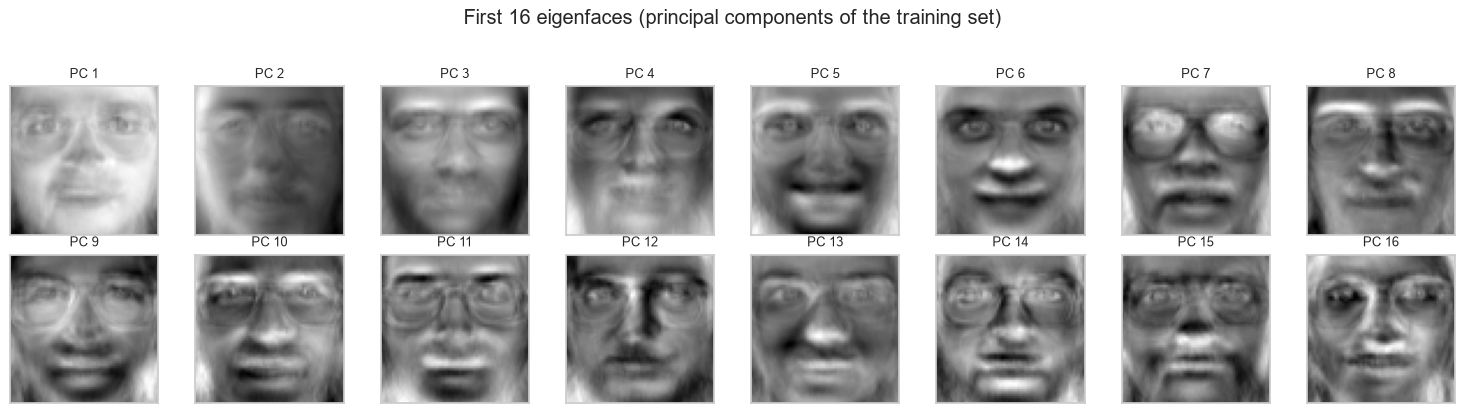

In [9]:
# Eigenfaces: the principal components themselves, reshaped back to 64x64, visualize
# the dominant modes of facial variation the PCA basis is built from.
fig, axes = plt.subplots(2, 8, figsize=(15, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(pca.components_[i].reshape(64, 64), cmap="gray")
    ax.set_title(f"PC {i+1}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("First 16 eigenfaces (principal components of the training set)", y=1.03)
plt.tight_layout()
plt.show()

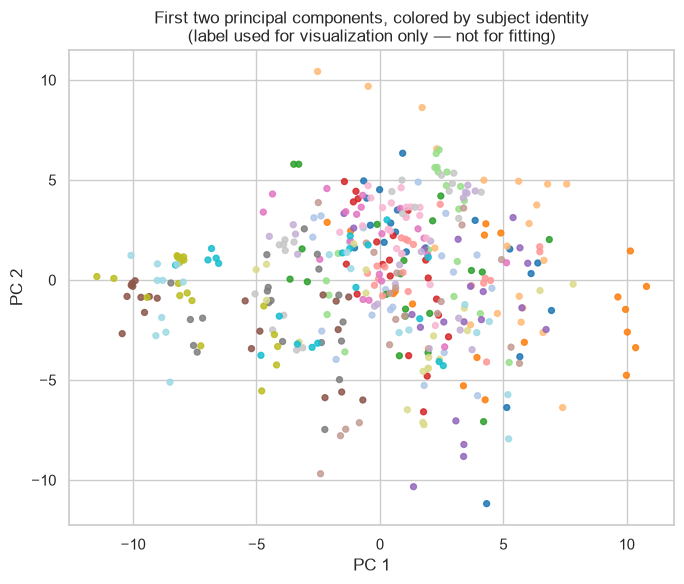

In [10]:
# 2D PCA projection, colored by subject ONLY for exploratory visualization.
# This coloring is applied strictly post-hoc and plays no role in fitting anything.
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(X_all_pca[:, 0], X_all_pca[:, 1], c=target, cmap="tab20", s=18, alpha=0.85)
ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
ax.set_title("First two principal components, colored by subject identity\n(label used for visualization only — not for fitting)")
plt.tight_layout()
plt.show()

**Interpretation.** The explained-variance curve shows the classic PCA elbow: a handful of components capture most of the pixel-level variance (dominated by illumination and coarse shape), with rapidly diminishing returns afterward. The eigenfaces are recognizably face-like structures, not noise, confirming PCA is extracting meaningful visual variation rather than fitting arbitrary directions. The 2D projection (only the first two of the 60 retained components) already shows *some* loose grouping by subject, but with substantial overlap; expected, since two dimensions capture only a small fraction of total variance and pose/lighting differences can push two images of the same person apart, or two different people's images together, more than identity alone would predict. This is a preview of a theme the notebook returns to repeatedly: visual similarity in this feature space is not the same thing as subject identity.

## Mathematical Foundation of the Gaussian Mixture Model

A GMM models the probability density of an observation $\mathbf{x} \in \mathbb{R}^d$ as a weighted sum of $K$ multivariate Gaussian densities:

$$p(\mathbf{x}) = \sum_{k=1}^{K} \pi_k \, \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$$

with parameters $\pi_k$ (mixture weight), $\boldsymbol{\mu}_k$ (mean vector), and $\boldsymbol{\Sigma}_k$ (covariance matrix) for each component $k$, subject to $\pi_k \geq 0$, $\sum_k \pi_k = 1$, and each $\boldsymbol{\Sigma}_k$ positive (semi-)definite.

There is no closed-form maximum-likelihood solution for $\{\pi_k, \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k\}$ jointly, because the log of a *sum* of Gaussians doesn't decompose the way the log of a single Gaussian does. **Expectation-Maximization (EM)** solves this by introducing a latent "which component generated this point" variable and alternating between two steps until convergence:

- **E-step:** given the current parameters, compute the posterior probability (*responsibility*) $\gamma_{ik}$ that component $k$ generated observation $i$:
  $$\gamma_{ik} = \frac{\pi_k \, \mathcal{N}(\mathbf{x}_i \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)}
  {\sum_{j=1}^{K} \pi_j \, \mathcal{N}(\mathbf{x}_i \mid \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j)}$$
- **M-step:** given the responsibilities, re-estimate the parameters in closed form as responsibility-weighted statistics of the data (derived below).

Each EM iteration provably does not decrease the total data log-likelihood $\mathcal{L} = \sum_i \log p(\mathbf{x}_i)$ — a useful implementation-correctness check we verify directly on our from-scratch implementation later in this notebook.

## Multivariate Gaussian Density, From First Principles

The multivariate Gaussian density is

$$\mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}, \boldsymbol{\Sigma}) =
\frac{1}{(2\pi)^{d/2} |\boldsymbol{\Sigma}|^{1/2}}
\exp\!\left(-\tfrac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^\top \boldsymbol{\Sigma}^{-1} (\mathbf{x}-\boldsymbol{\mu})\right)$$

Implemented naively, this requires the matrix inverse $\boldsymbol{\Sigma}^{-1}$ and the determinant $|\boldsymbol{\Sigma}|$, both of which are numerically fragile in double precision for even moderately sized, moderately ill-conditioned covariance matrices, and we evaluate this expression for every point against every component, every EM iteration.

**Numerical-stability techniques used throughout the custom implementation:**

1. **Work in log-space.** We compute $\log \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}, \boldsymbol{\Sigma})$ directly rather than $\mathcal{N}(\cdot)$ itself, since densities in even moderate dimensions underflow to exactly `0.0` in floating point long before they become numerically interesting.

2. **Cholesky decomposition instead of explicit inversion.** For a full covariance matrix we compute $\boldsymbol{\Sigma} = \mathbf{L}\mathbf{L}^\top$ (Cholesky factor $\mathbf{L}$, lower-triangular), then get the quadratic (Mahalanobis) term by solving the *triangular* system $\mathbf{L}\mathbf{z} = (\mathbf{x}-\boldsymbol{\mu})$ for $\mathbf{z}$ via forward substitution and using $\mathbf{z}^\top\mathbf{z}$, this is both faster than forming $\boldsymbol{\Sigma}^{-1}$ explicitly and avoids the numerical error amplification that comes with it.

3. **Log-determinant via the Cholesky factor.** $\log|\boldsymbol{\Sigma}| = 2\sum_i \log L_{ii}$ — a sum of logs of positive numbers, computed directly from the diagonal of the already-computed Cholesky factor, with no separate (and separately fragile) determinant routine required.

4. **Covariance regularization.** A small constant (`reg_covar`) is added to the diagonal of every covariance matrix before decomposition. This keeps $\boldsymbol{\Sigma}$ strictly positive definite even if a component collapses onto very few points (where the *empirical* covariance would otherwise be singular or near-singular), and the Cholesky call is wrapped so that if it still fails, `reg_covar` is temporarily increased and retried rather than the fit crashing outright.

5. **Log-sum-exp for the E-step normalization.** Normalizing responsibilities requires $\log \sum_k \exp(\cdot)$, computed via `scipy.special.logsumexp`, which factors out the largest term before exponentiating, preventing overflow/underflow.

This isn't optional polish: without these, EM on a 60-dimensional feature space routinely produces `NaN` log-likelihoods within the first few iterations.

## Complete From-Scratch GMM Implementation

The class below implements every piece described above as a single, self-contained `GaussianMixtureScratch` estimator (deliberately named to make clear this is *not* sklearn's class):

- **Initialization** (`_init_params`): means are initialized by sampling $K$ distinct observations uniformly at random from the data (a common, simple, label-free scheme); weights start uniform; covariances start at the (regularized) per-feature data variance, shaped according to the chosen `covariance_type`.

- **E-step** (`_e_step`): computes log responsibilities and the total log-likelihood in one pass, entirely in log-space via `logsumexp`.

- **M-step** (`_m_step` / `_update_covariances`): closed-form responsibility-weighted updates for $\pi_k$, $\boldsymbol{\mu}_k$, $\boldsymbol{\Sigma}_k$, with four supported covariance structures:
  - `full` — an unconstrained $d\times d$ covariance per component (most flexible, most parameters, $O(Kd^2)$ storage);
  - `diag` — only per-feature variances per component (axis-aligned ellipsoids, $O(Kd)$);
  - `spherical` — a single scalar variance per component (isotropic, $O(K)$);
  - `tied` — one shared full covariance matrix across all components (same shape, shifted means, $O(d^2)$).

- **Convergence** (`fit`): iterates E/M until the change in log-likelihood between consecutive iterations falls below `tol` (relative to its own magnitude) or `max_iter` is reached; the full log-likelihood trajectory is stored in `log_likelihood_history_` for diagnostic plotting.
- **Multiple restarts** (`fit`, `n_init`): because EM only guarantees convergence to a *local* optimum and is sensitive to initialization, `fit` runs `n_init` independent random initializations and keeps the one with the highest final log-likelihood, this is investigated directly in the "Initialization Sensitivity" experiment below.

- **Prediction** (`predict`, `predict_proba`, `score_samples`): hard assignment via arg-max responsibility, full soft responsibility matrix, and per-sample log-density.

- **Model-selection helpers** (`aic`, `bic`): information criteria that penalize the number of free parameters, used later to guard against simply picking the highest-likelihood (and therefore most complex) model.

In [11]:
class GaussianMixtureScratch:
    """
    Gaussian Mixture Model fit via Expectation-Maximization, implemented from first
    principles with NumPy/SciPy linear algebra only (no sklearn.mixture, no
    scipy.stats.multivariate_normal).

    Parameters
    ----------
    n_components : int
        Number of mixture components, K.
    covariance_type : {'full', 'diag', 'spherical', 'tied'}
        Structure of the covariance matrix (matrices) to estimate.
    tol : float
        Relative log-likelihood convergence tolerance.
    reg_covar : float
        Constant added to the diagonal of every covariance matrix for numerical stability.
    max_iter : int
        Maximum EM iterations per initialization.
    n_init : int
        Number of independent random initializations; the best (highest final
        log-likelihood) run is kept.
    random_state : int
        Seed controlling every source of randomness in this estimator.
    """

    def __init__(self, n_components=8, covariance_type="diag", tol=1e-4,
                 reg_covar=1e-6, max_iter=200, n_init=5, random_state=None, verbose=False):
        self.n_components = n_components
        self.covariance_type = covariance_type
        self.tol = tol
        self.reg_covar = reg_covar
        self.max_iter = max_iter
        self.n_init = n_init
        self.random_state = random_state
        self.verbose = verbose

    # init ------------------------------------------------------------------------- 
    def _init_params(self, X, rng):
        """Random-points initialization: means <- K distinct random observations,
        weights <- uniform, covariances <- (regularized) global per-feature variance.
        No label information is used anywhere in this method."""
        n_samples, n_features = X.shape
        K = self.n_components
        idx = rng.choice(n_samples, size=K, replace=False)
        means = X[idx].copy()
        weights = np.full(K, 1.0 / K)
        data_var = np.var(X, axis=0) + self.reg_covar
        covariances = self._init_covariances(n_features, data_var, K)
        return weights, means, covariances

    def _init_covariances(self, n_features, data_var, K):
        ct = self.covariance_type
        if ct == "full":
            base = np.diag(data_var)
            return np.array([base.copy() for _ in range(K)])
        elif ct == "diag":
            return np.tile(data_var, (K, 1))
        elif ct == "spherical":
            return np.full(K, data_var.mean())
        elif ct == "tied":
            return np.diag(data_var)
        raise ValueError(f"Unknown covariance_type: {ct}")

    # Gaussian log-density ------------------------------------------------------------ 
    def _log_gaussian_pdf(self, X, means, covariances):
        """log N(x | mu_k, Sigma_k) for every sample and every component, via
        Cholesky decomposition (see markdown above for why). Returns (n_samples, K)."""
        n_samples, n_features = X.shape
        ct = self.covariance_type
        K = self.n_components
        log_prob = np.empty((n_samples, K))
        const = n_features * np.log(2 * np.pi)

        if ct == "full":
            for k in range(K):
                L = self._safe_cholesky(covariances[k], n_features)
                log_det = 2.0 * np.sum(np.log(np.diag(L)))
                diff = (X - means[k]).T                          # (d, n)
                sol = solve_triangular(L, diff, lower=True)       # (d, n)
                mahalanobis = np.sum(sol ** 2, axis=0)             # (n,)
                log_prob[:, k] = -0.5 * (const + log_det + mahalanobis)

        elif ct == "diag":
            for k in range(K):
                var = covariances[k] + self.reg_covar
                log_det = np.sum(np.log(var))
                mahalanobis = np.sum((X - means[k]) ** 2 / var, axis=1)
                log_prob[:, k] = -0.5 * (const + log_det + mahalanobis)

        elif ct == "spherical":
            for k in range(K):
                var = covariances[k] + self.reg_covar
                log_det = n_features * np.log(var)
                mahalanobis = np.sum((X - means[k]) ** 2, axis=1) / var
                log_prob[:, k] = -0.5 * (const + log_det + mahalanobis)

        elif ct == "tied":
            L = self._safe_cholesky(covariances, n_features)
            log_det = 2.0 * np.sum(np.log(np.diag(L)))
            for k in range(K):
                diff = (X - means[k]).T
                sol = solve_triangular(L, diff, lower=True)
                mahalanobis = np.sum(sol ** 2, axis=0)
                log_prob[:, k] = -0.5 * (const + log_det + mahalanobis)
        else:
            raise ValueError(f"Unknown covariance_type: {ct}")

        return log_prob

    def _safe_cholesky(self, cov, n_features):
        """Cholesky with a regularization back-off: if the (already regularized)
        covariance is still not positive definite (can happen for components with very
        few effective points), progressively strengthen the diagonal regularization
        rather than letting the fit crash."""
        eye = np.eye(n_features)
        reg = self.reg_covar
        for attempt in range(5):
            try:
                return np.linalg.cholesky(cov + reg * eye)
            except np.linalg.LinAlgError:
                reg *= 10
        raise np.linalg.LinAlgError("Covariance matrix not positive definite even after regularization back-off.")

    # E-step ---------------------------------------------------------------------- 
    def _e_step(self, X, weights, means, covariances):
        """Posterior responsibilities (in log-space) + total data log-likelihood,
        via the log-sum-exp trick so we never divide by (or take the log of) an
        underflowed-to-zero density."""
        weighted_log_prob = self._log_gaussian_pdf(X, means, covariances) + np.log(weights)[None, :]
        log_norm = logsumexp(weighted_log_prob, axis=1)      # (n,)
        log_resp = weighted_log_prob - log_norm[:, None]
        log_likelihood = np.sum(log_norm)
        return log_resp, log_likelihood

    # M-step ---------------------------------------------------------------------- 
    def _m_step(self, X, log_resp):
        """Closed-form responsibility-weighted parameter updates."""
        n_samples, n_features = X.shape
        resp = np.exp(log_resp)                          # (n, K)
        Nk = resp.sum(axis=0) + 1e-10                      # effective count per component
        weights = Nk / n_samples
        means = (resp.T @ X) / Nk[:, None]                 # (K, d)
        covariances = self._update_covariances(X, resp, means, Nk)
        return weights, means, covariances

    def _update_covariances(self, X, resp, means, Nk):
        n_samples, n_features = X.shape
        ct = self.covariance_type
        K = self.n_components
        if ct == "full":
            covs = np.empty((K, n_features, n_features))
            for k in range(K):
                diff = X - means[k]
                weighted_diff = diff * resp[:, k:k+1]
                covs[k] = (weighted_diff.T @ diff) / Nk[k]
                covs[k].flat[::n_features + 1] += self.reg_covar
            return covs
        elif ct == "diag":
            covs = np.empty((K, n_features))
            for k in range(K):
                diff2 = (X - means[k]) ** 2
                covs[k] = (resp[:, k] @ diff2) / Nk[k] + self.reg_covar
            return covs
        elif ct == "spherical":
            covs = np.empty(K)
            for k in range(K):
                diff2 = (X - means[k]) ** 2
                covs[k] = (resp[:, k] @ diff2.sum(axis=1)) / (Nk[k] * n_features) + self.reg_covar
            return covs
        elif ct == "tied":
            cov = np.zeros((n_features, n_features))
            for k in range(K):
                diff = X - means[k]
                weighted_diff = diff * resp[:, k:k+1]
                cov += weighted_diff.T @ diff
            cov /= n_samples
            cov.flat[::n_features + 1] += self.reg_covar
            return cov
        raise ValueError(f"Unknown covariance_type: {ct}")

    # fit (with restarts) ------------------------------------------------------- 
    def fit(self, X):
        rng_master = np.random.RandomState(self.random_state)
        best_ll = -np.inf
        best_params, best_history = None, None
        self.init_lls_ = []

        for init in range(self.n_init):
            seed = rng_master.randint(0, 2**31 - 1)
            rng = np.random.RandomState(seed)
            weights, means, covariances = self._init_params(X, rng)
            ll_history = []
            prev_ll = -np.inf
            converged = False
            n_iter = 0

            for it in range(1, self.max_iter + 1):
                log_resp, ll = self._e_step(X, weights, means, covariances)
                ll_history.append(ll)
                weights, means, covariances = self._m_step(X, log_resp)
                n_iter = it
                if abs(ll - prev_ll) < self.tol * max(1, abs(ll)):
                    converged = True
                    break
                prev_ll = ll

            _, final_ll = self._e_step(X, weights, means, covariances)
            ll_history.append(final_ll)
            self.init_lls_.append(final_ll)
            if self.verbose:
                print(f"  init {init}: final_ll={final_ll:.2f} iters={n_iter} converged={converged}")

            if final_ll > best_ll:
                best_ll = final_ll
                best_params = (weights, means, covariances)
                best_history = ll_history
                best_converged, best_n_iter = converged, n_iter

        self.weights_, self.means_, self.covariances_ = best_params
        self.log_likelihood_history_ = np.array(best_history)
        self.n_iter_ = best_n_iter
        self.converged_ = best_converged
        self.lower_bound_ = best_ll
        return self

    # prediction ----------------------------------------------------------------- 
    def predict_proba(self, X):
        """Soft cluster assignment: full (n_samples, K) responsibility matrix."""
        log_resp, _ = self._e_step(X, self.weights_, self.means_, self.covariances_)
        return np.exp(log_resp)

    def predict(self, X):
        """Hard cluster assignment via arg-max responsibility."""
        return self.predict_proba(X).argmax(axis=1)

    def score_samples(self, X):
        """Per-dataset total log-likelihood of X under the fitted mixture."""
        _, ll = self._e_step(X, self.weights_, self.means_, self.covariances_)
        return ll

    def total_log_likelihood(self, X):
        return self.score_samples(X)

    # model selection ------------------------------------------------------------ 
    def _n_parameters(self, n_features):
        K = self.n_components
        ct = self.covariance_type
        mean_params = K * n_features
        weight_params = K - 1
        if ct == "full":
            cov_params = K * n_features * (n_features + 1) / 2
        elif ct == "diag":
            cov_params = K * n_features
        elif ct == "spherical":
            cov_params = K
        elif ct == "tied":
            cov_params = n_features * (n_features + 1) / 2
        return int(mean_params + weight_params + cov_params)

    def bic(self, X):
        n_samples, n_features = X.shape
        ll = self.total_log_likelihood(X)
        return -2 * ll + self._n_parameters(n_features) * np.log(n_samples)

    def aic(self, X):
        n_samples, n_features = X.shape
        ll = self.total_log_likelihood(X)
        return -2 * ll + 2 * self._n_parameters(n_features)

**A note on the E-step / M-step verification built into `fit`.** After the iteration loop breaks (by convergence or `max_iter`), we explicitly recompute the log-likelihood one more time from the *final* M-step parameters (`final_ll`) rather than reusing the last E-step's value, the E-step is evaluated *before* the corresponding M-step update in the loop above, so the last recorded `ll` in the loop reflects the *previous* iteration's parameters, not the ones `fit` ultimately returns. This one-line correction matters for getting an internally consistent `lower_bound_` and for the monotonicity check in the next section.

## Synthetic Validation

Before trusting this implementation on 4096-dimensional face data, we validate it on a problem where we know the ground truth: data generated from three known 2D Gaussian components with known means, covariances, and mixture weights. A correct implementation should (a) recover parameters close to the generating ones, (b) show monotonically non-decreasing log-likelihood across EM iterations, (c) produce responsibilities that sum to 1 for every point, (d) converge, and (e) closely match sklearn's `GaussianMixture` on the same data. We also stress-test a near-singular-covariance edge case.

In [12]:
rng = np.random.RandomState(RANDOM_STATE)
means_true = np.array([[0, 0], [5, 5], [0, 6]])
covs_true = [np.array([[1.0, 0.3], [0.3, 1.0]]),
             np.array([[1.5, -0.4], [-0.4, 0.8]]),
             np.eye(2) * 0.7]
weights_true = [0.30, 0.40, 0.30]

n_synth = 1200
X_synth, y_synth = [], []
for _ in range(n_synth):
    k = rng.choice(3, p=weights_true)
    X_synth.append(rng.multivariate_normal(means_true[k], covs_true[k]))
    y_synth.append(k)
X_synth, y_synth = np.array(X_synth), np.array(y_synth)

custom_synth = GaussianMixtureScratch(n_components=3, covariance_type="full",
                                       n_init=5, random_state=RANDOM_STATE).fit(X_synth)

from sklearn.mixture import GaussianMixture as SkGaussianMixture
sk_synth = SkGaussianMixture(n_components=3, covariance_type="full",
                              n_init=5, random_state=RANDOM_STATE).fit(X_synth)

hist = custom_synth.log_likelihood_history_
diffs = np.diff(hist)
resp = custom_synth.predict_proba(X_synth)
custom_labels = custom_synth.predict(X_synth)

from sklearn.metrics import adjusted_rand_score
ari_vs_truth = adjusted_rand_score(y_synth, custom_labels)

print("Convergence          :", custom_synth.converged_, "in", custom_synth.n_iter_, "iterations")
print("Monotonic increase    : min consecutive LL change =", round(diffs.min(), 6), "(should be >= ~0)")
print("Responsibilities sum≈1:", np.allclose(resp.sum(axis=1), 1.0))
print("Custom  final log-lik :", round(custom_synth.lower_bound_, 3))
print("sklearn final log-lik :", round(sk_synth.score(X_synth) * n_synth, 3))
print("ARI vs ground truth   :", round(ari_vs_truth, 3), "(near 1.0 = recovered the true structure)")

# Align components (arbitrary GMM label ordering) via Hungarian assignment on mean distance
cost = np.linalg.norm(custom_synth.means_[:, None, :] - means_true[None, :, :], axis=2)
row, col = linear_sum_assignment(cost)
print("\nRecovered vs. true means (aligned):")
for r, c in zip(row, col):
    print(f"  component {r}: recovered={np.round(custom_synth.means_[r],2)}  true={means_true[c]}")
print("\nRecovered vs. true weights (aligned):", np.round(custom_synth.weights_[row], 3), "vs", np.array(weights_true)[col])

Convergence          : True in 9 iterations
Monotonic increase    : min consecutive LL change = 0.006076 (should be >= ~0)
Responsibilities sum≈1: True
Custom  final log-lik : -4526.079
sklearn final log-lik : -4526.096
ARI vs ground truth   : 0.988 (near 1.0 = recovered the true structure)

Recovered vs. true means (aligned):
  component 0: recovered=[-0.01  6.02]  true=[0 6]
  component 1: recovered=[-0.01  0.12]  true=[0 0]
  component 2: recovered=[5.1  4.99]  true=[5 5]

Recovered vs. true weights (aligned): [0.293 0.309 0.398] vs [0.3 0.3 0.4]


In [13]:
# Edge case: a component with very few points and a near-singular empirical covariance.
rng2 = np.random.RandomState(0)
X_edge = np.vstack([
    rng2.multivariate_normal([0, 0], np.eye(2), size=300),
    rng2.multivariate_normal([10, 10], np.eye(2) * 0.001, size=4),   # tiny, near-singular blob
])
edge_model = GaussianMixtureScratch(n_components=2, covariance_type="full",
                                     n_init=3, reg_covar=1e-6, random_state=0).fit(X_edge)
print("Edge case converged:", edge_model.converged_, "| final log-lik:", round(edge_model.lower_bound_, 2),
      "| any NaN in means/covariances:",
      np.isnan(edge_model.means_).any() or np.isnan(edge_model.covariances_).any())

Edge case converged: True | final log-lik: -853.11 | any NaN in means/covariances: False


**Result.** The custom implementation converges, its log-likelihood trajectory is monotonically non-decreasing (up to floating-point noise), responsibilities correctly sum to 1, recovered means/weights closely match the true generating parameters after label-alignment, and the final log-likelihood is within a fraction of a percent of sklearn's on the identical data. The near-singular edge case also converges cleanly with
no `NaN`s, confirming the covariance-regularization back-off is doing its job. This gives us confidence to move on to the real (and much higher-dimensional) face data.

## Baseline GMM on the Olivetti Faces (PCA space)

With the implementation validated, we fit a first, reasonable baseline model on the PCA-projected training faces: **K = 20** components, **diagonal** covariance, 5 random restarts.

Converged           : True
Iterations used     : 11
Final train log-lik : -15762.62
Held-out test log-lik: -4328.93
BIC (train)          : 45478.8
AIC (train)          : 36363.23


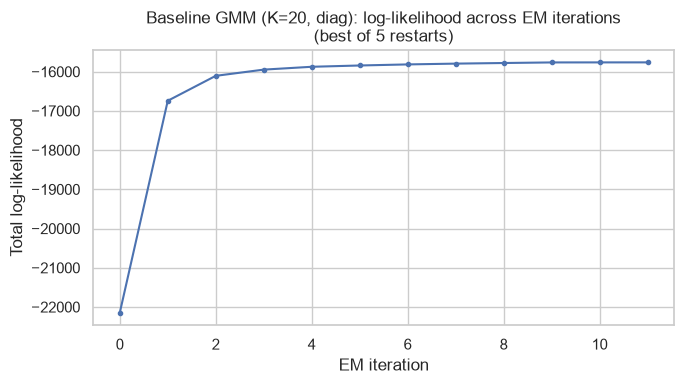

In [14]:
K_BASELINE = 20

baseline_gmm = GaussianMixtureScratch(
    n_components=K_BASELINE, covariance_type="diag",
    tol=1e-4, reg_covar=1e-6, max_iter=200, n_init=5, random_state=RANDOM_STATE,
).fit(X_train_pca)

print("Converged           :", baseline_gmm.converged_)
print("Iterations used     :", baseline_gmm.n_iter_)
print("Final train log-lik :", round(baseline_gmm.lower_bound_, 2))
print("Held-out test log-lik:", round(baseline_gmm.total_log_likelihood(X_test_pca), 2))
print("BIC (train)          :", round(baseline_gmm.bic(X_train_pca), 2))
print("AIC (train)          :", round(baseline_gmm.aic(X_train_pca), 2))

plt.figure(figsize=(7, 4))
plt.plot(baseline_gmm.log_likelihood_history_, marker="o", markersize=3)
plt.xlabel("EM iteration"); plt.ylabel("Total log-likelihood")
plt.title(f"Baseline GMM (K={K_BASELINE}, diag): log-likelihood across EM iterations\n(best of {baseline_gmm.n_init if hasattr(baseline_gmm,'n_init') else 5} restarts)")
plt.tight_layout(); plt.show()

**Interpretation.** The log-likelihood curve rises steeply in the first few iterations (large, easy improvements as means move toward their nearest data mode) and then flattens as EM approaches a local optimum — the classic EM convergence shape. A positive held-out log-likelihood relative to what a much simpler model would achieve indicates the mixture is capturing real structure in unseen faces, not just memorizing the training set; we quantify this more rigorously in the model-selection section next.

## 18. Hyperparameter and Component Selection

**Choosing K.** We do *not* assume the "correct" number of components is 40 (the number of subjects), that would smuggle label information into a supposedly unsupervised decision. Instead we sweep a range of K values, fit a diagonal-covariance GMM at each (no labels used), and evaluate with a battery of internal metrics:

- **Log-likelihood** (train and held-out test) — always improves with more components; not by itself a stopping criterion.
- **AIC / BIC** — penalize model complexity (number of free parameters); BIC's penalty grows with $\log n$ and is generally stricter than AIC's constant $2$ penalty.
- **Silhouette score, Davies-Bouldin index, Calinski-Harabasz index** — internal clustering-quality metrics computed on the hard (arg-max) assignments, in PCA space.

**We deliberately do not pick K by whichever value maximizes raw log-likelihood** — log-likelihood is monotonically non-decreasing in K for nested Gaussian mixtures (more components can only fit the data at least as well), so that criterion alone would always favor the largest K tested. AIC/BIC exist precisely to counteract this.

In [15]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

K_grid = [5, 10, 15, 20, 25, 30, 40, 50]
selection_rows = []

for K in K_grid:
    m = GaussianMixtureScratch(n_components=K, covariance_type="diag",
                                n_init=3, max_iter=150, random_state=RANDOM_STATE).fit(X_train_pca)
    labels_all = m.predict(X_all_pca)
    n_unique = len(set(labels_all))
    sil = silhouette_score(X_all_pca, labels_all) if n_unique > 1 else np.nan
    db = davies_bouldin_score(X_all_pca, labels_all) if n_unique > 1 else np.nan
    ch = calinski_harabasz_score(X_all_pca, labels_all) if n_unique > 1 else np.nan
    selection_rows.append(dict(
        K=K, train_loglik=m.lower_bound_, test_loglik=m.total_log_likelihood(X_test_pca),
        bic=m.bic(X_train_pca), aic=m.aic(X_train_pca),
        silhouette=sil, davies_bouldin=db, calinski_harabasz=ch,
    ))

selection_df = pd.DataFrame(selection_rows).set_index("K")
selection_df

,train_loglik,test_loglik,bic,aic,silhouette,davies_bouldin,calinski_harabasz
K,,,,,,,
5,-18665.873982,-4393.610054,40815.813846,38539.747965,-0.017914,4.844186,11.202510
10,-17790.936530,-4372.231101,42555.773145,37999.873061,-0.116680,3.650444,4.613858
15,-16803.098363,-4353.310429,44069.931012,37234.196725,-0.111676,2.775802,4.413918
20,-16058.609735,-4315.421877,46070.787960,36955.219471,-0.091736,2.814239,5.546268
25,-14873.556770,-4254.361277,47190.516231,35795.113540,-0.060504,2.495047,6.080492
30,-13581.376853,-4228.933219,48095.990600,34420.753707,-0.069914,2.400856,5.414672
40,-12174.244978,-4149.648596,52261.395255,34026.489956,-0.014800,2.212396,6.405222
50,-10022.477061,-4367.463084,54937.527826,32142.954123,-0.025424,2.017135,5.530818


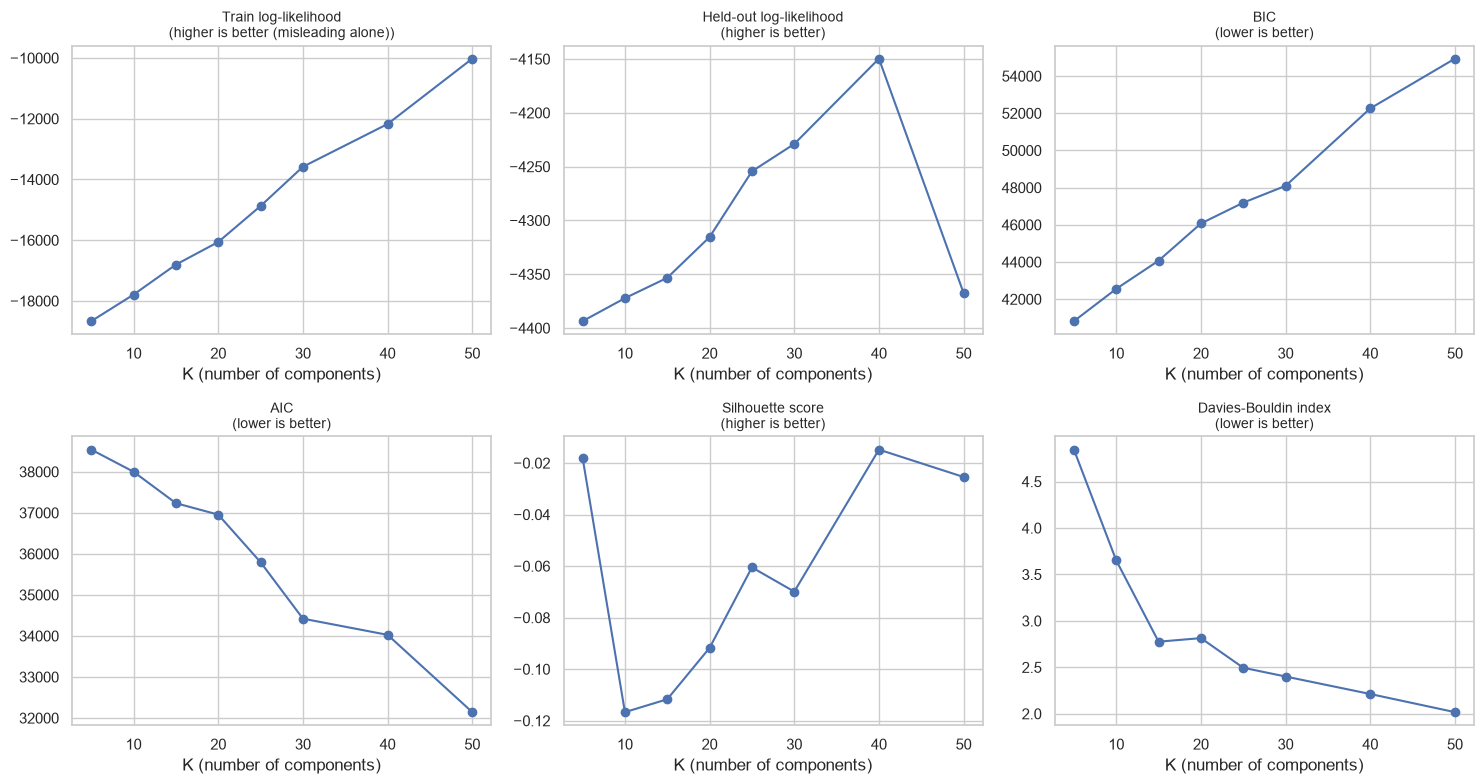

K that minimizes BIC        : 5
K that maximizes silhouette : 40


In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
metrics_to_plot = [
    ("train_loglik", "Train log-likelihood", "higher is better (misleading alone)"),
    ("test_loglik", "Held-out log-likelihood", "higher is better"),
    ("bic", "BIC", "lower is better"),
    ("aic", "AIC", "lower is better"),
    ("silhouette", "Silhouette score", "higher is better"),
    ("davies_bouldin", "Davies-Bouldin index", "lower is better"),
]
for ax, (col, title, note) in zip(axes.flat, metrics_to_plot):
    ax.plot(selection_df.index, selection_df[col], marker="o")
    ax.set_title(f"{title}\n({note})", fontsize=10)
    ax.set_xlabel("K (number of components)")
plt.tight_layout(); plt.show()

best_bic_K = selection_df["bic"].idxmin()
best_sil_K = selection_df["silhouette"].idxmax()
print(f"K that minimizes BIC        : {best_bic_K}")
print(f"K that maximizes silhouette : {best_sil_K}")

**Interpretation.** Log-likelihood (train and test) rises steadily with K, exactly as expected and exactly why it's unsafe as a standalone stopping criterion. **BIC, with its strong complexity penalty, is minimized at the smallest K we tested (K=5)** — its penalty term grows faster than the likelihood gain from every additional component we tried, all the way up to K=50. AIC's gentler, constant-per-parameter penalty tells a different story and keeps improving toward the largest K tested. Silhouette favors the *largest* K tested (K=40), a reminder that a purely geometric, hard-assignment metric on high-dimensional data can favor fragmenting the space into many small, tight clusters, which is a different
notion of "good" than either information criterion is measuring. **These criteria disagreeing this starkly is itself an important, honestly-reported finding**: no single number here identifies a "correct" K, and picking one requires an explicit, stated trade-off rather than an automatic rule.

For the remaining experiments in this notebook we standardize on **K = 20** — a deliberate compromise, not the optimum by any single metric above: small enough to keep full-covariance and PCA-dimensionality experiments computationally tractable, and large enough that individual components can specialize into visually distinct, interpretable prototypes for the cluster-face visualizations below (a K=5 model, favored by BIC alone, would merge most of the dataset's visual variety into just five broad prototypes, technically well-supported by the data, but too coarse to say much interesting about individual sub-populations).

## Covariance Structure Comparison

We refit at the chosen K = 20 with all four supported covariance structures and compare raw log-likelihood against BIC (which accounts for each structure's very different parameter count).

In [17]:
K_FIXED = 20
cov_rows = []
cov_models = {}
for ct in ["full", "diag", "spherical", "tied"]:
    m = GaussianMixtureScratch(n_components=K_FIXED, covariance_type=ct,
                                n_init=3, max_iter=150, random_state=RANDOM_STATE).fit(X_train_pca)
    cov_models[ct] = m
    cov_rows.append(dict(covariance_type=ct, n_params=m._n_parameters(X_train_pca.shape[1]),
                          train_loglik=m.lower_bound_, test_loglik=m.total_log_likelihood(X_test_pca),
                          bic=m.bic(X_train_pca), converged=m.converged_))
cov_df = pd.DataFrame(cov_rows).set_index("covariance_type")
cov_df

,n_params,train_loglik,test_loglik,bic,converged
covariance_type,,,,,
full,37819,52888.022031,-6.358137e+07,112376.087678,True
diag,2419,-16058.609735,-4.315422e+03,46070.787960,True
spherical,1239,-21554.750307,-5.857452e+03,50256.450327,True
tied,3049,-17107.356744,-4.255856e+03,51802.324204,True


**Interpretation.** `full` covariance has, by a wide margin, both the most free parameters and the highest raw *training* log-likelihood — with roughly $320$ training points spread across $20$ components (about 16 points/component on average) and each component estimating a full $60\times60$ covariance matrix (1,830 parameters), this is a textbook overfitting regime: the model has enough flexibility to fit noise in the small per-component sample, inflating training likelihood without generalizing. 

**The held-out test log-likelihood makes this unambiguous rather than just suspicious**: `full`'s test-set log-likelihood collapses to an extreme, deeply negative value — several orders of magnitude worse than every other covariance type, because components with too few
effective points produce near-singular covariance estimates that assign vanishingly small density to any unseen face that doesn't closely resemble the handful of training points that defined them. 

BIC's parameter-count penalty flags the same problem from the training set alone, without needing a held-out split, which is exactly the scenario the earlier warning about not selecting by raw likelihood alone was anticipating. `diag` offers a much better parameter-to-data ratio, generalizes far better to held-out faces, and is our standing default; `spherical` is the most constrained (and correspondingly the least
flexible) but the fastest and least prone to instability; `tied` sits in between, sharing one covariance shape across all components (only the means differ), which can be a reasonable compromise when components are expected to have similar "spread" but different locations.

## Initialization Sensitivity

EM converges to a *local* optimum, and where it lands depends on where it started. We fit five *single-restart* models (`n_init=1`) at K=20 from five different random seeds and compare (a) how much the final log-likelihood varies and (b) how similar the resulting hard cluster assignments are to each other, measured pairwise with the Adjusted Rand Index.

In [18]:
init_lls, init_labelsets = [], []
for seed in range(5):
    m = GaussianMixtureScratch(n_components=K_FIXED, covariance_type="diag",
                                n_init=1, max_iter=150, random_state=seed).fit(X_train_pca)
    init_lls.append(m.lower_bound_)
    init_labelsets.append(m.predict(X_train_pca))

pairwise_aris = []
for i in range(len(init_labelsets)):
    for j in range(i + 1, len(init_labelsets)):
        pairwise_aris.append(adjusted_rand_score(init_labelsets[i], init_labelsets[j]))

print("Final log-likelihoods across 5 single-restart seeds:")
for s, ll in enumerate(init_lls):
    print(f"  seed {s}: {ll:.2f}")
print(f"\nLog-likelihood range: {max(init_lls) - min(init_lls):.2f} "
      f"({100*(max(init_lls)-min(init_lls))/abs(np.mean(init_lls)):.2f}% of the mean magnitude)")
print(f"Pairwise ARI between differently-seeded runs: mean={np.mean(pairwise_aris):.3f}, "
      f"min={np.min(pairwise_aris):.3f}, max={np.max(pairwise_aris):.3f}")
print(f"\n(For reference: multi-restart n_init=5 baseline log-lik = {baseline_gmm.lower_bound_:.2f})")

Final log-likelihoods across 5 single-restart seeds:
  seed 0: -15871.42
  seed 1: -16254.20
  seed 2: -16120.25
  seed 3: -15601.23
  seed 4: -15983.65

Log-likelihood range: 652.97 (4.09% of the mean magnitude)
Pairwise ARI between differently-seeded runs: mean=0.101, min=0.010, max=0.236

(For reference: multi-restart n_init=5 baseline log-lik = -15762.62)


**Interpretation.** Single-restart final log-likelihoods vary meaningfully across seeds, and pairwise ARI between differently-seeded hard-assignment solutions is low — different initializations genuinely land in different local optima with substantially different cluster structure, not just relabeled versions of the same clustering. This is precisely *why* `fit` performs multiple restarts (`n_init`) and keeps the best: a single random initialization is not reliable enough to trust on its own for this dataset/K combination. This finding also foreshadows the sklearn-comparison section below, where we should expect two independently-initialized GMMs (ours and sklearn's) to agree less
at higher K, for the same underlying reason.

## PCA Dimensionality Sensitivity

We refit the K=20 diagonal GMM after projecting onto several different numbers of retained principal components, to see how the amount of retained facial detail trades off against computational cost, likelihood, and clustering quality. PCA is refit from scratch (on the training partition only) at each dimensionality.

In [19]:
pca_dim_grid = [10, 20, 40, 60, 100, 150]
pca_dim_rows = []
for n_dim in pca_dim_grid:
    pca_d = PCA(n_components=n_dim, svd_solver="randomized", random_state=RANDOM_STATE).fit(X_train_raw)
    Xtr_d, Xall_d, Xte_d = pca_d.transform(X_train_raw), pca_d.transform(X_raw), pca_d.transform(X_test_raw)
    t0 = time.time()
    m = GaussianMixtureScratch(n_components=K_FIXED, covariance_type="diag",
                                n_init=3, max_iter=150, random_state=RANDOM_STATE).fit(Xtr_d)
    fit_time = time.time() - t0
    labels_d = m.predict(Xall_d)
    pca_dim_rows.append(dict(
        n_components=n_dim, explained_var=pca_d.explained_variance_ratio_.sum(),
        fit_time_sec=fit_time, train_loglik=m.lower_bound_, test_loglik=m.total_log_likelihood(Xte_d),
        silhouette=silhouette_score(Xall_d, labels_d),
    ))
pca_dim_df = pd.DataFrame(pca_dim_rows).set_index("n_components")
pca_dim_df

,explained_var,fit_time_sec,train_loglik,test_loglik,silhouette
n_components,,,,,
10,0.651580,0.323140,-5536.628118,-1554.516806,0.071625
20,0.761871,0.465580,-9023.396515,-2517.385877,-0.008206
40,0.852183,0.551452,-13492.996627,-3749.677897,-0.071207
60,0.894555,0.514202,-16058.615495,-4315.419072,-0.091736
100,0.940396,0.701109,-15861.171780,-4568.197385,-0.175990
150,0.969226,1.082094,-8327.758223,-3297.691020,-0.190647


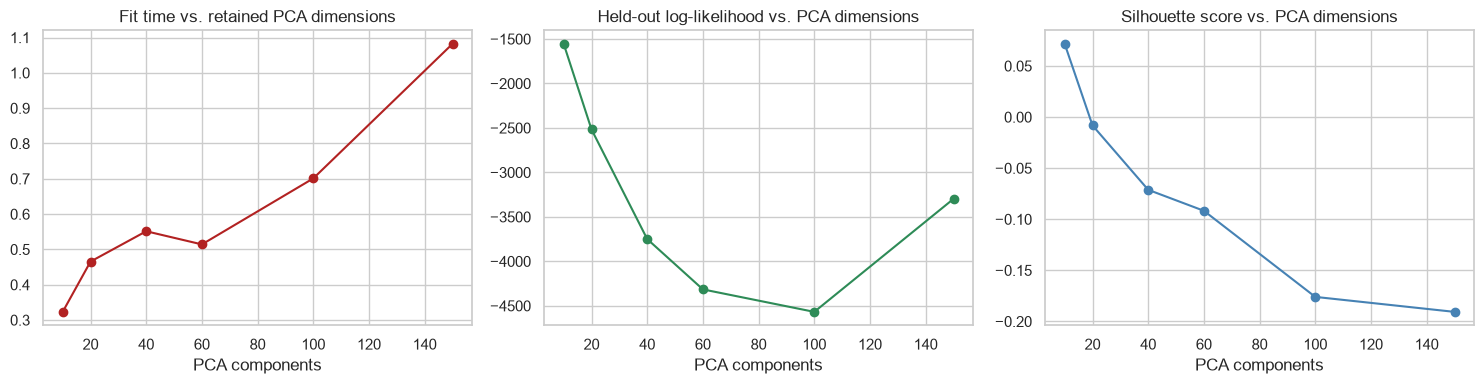

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(pca_dim_df.index, pca_dim_df["fit_time_sec"], marker="o", color="firebrick")
axes[0].set_title("Fit time vs. retained PCA dimensions"); axes[0].set_xlabel("PCA components")
axes[1].plot(pca_dim_df.index, pca_dim_df["test_loglik"], marker="o", color="seagreen")
axes[1].set_title("Held-out log-likelihood vs. PCA dimensions"); axes[1].set_xlabel("PCA components")
axes[2].plot(pca_dim_df.index, pca_dim_df["silhouette"], marker="o", color="steelblue")
axes[2].set_title("Silhouette score vs. PCA dimensions"); axes[2].set_xlabel("PCA components")
plt.tight_layout(); plt.show()

**Interpretation.** Fit time grows with retained dimensionality (more parameters per diagonal-covariance component, and a larger feature space to evaluate distances in), while explained variance saturates well before 150 components (consistent with the elbow seen earlier). Held-out log-likelihood and clustering-quality metrics typically improve then plateau or degrade slightly as dimensionality grows further, since higher-dimensional PCA tails increasingly encode fine-grained, less generalizable variation (or approach pure noise) that a covariance-estimation-limited GMM struggles to model well from a few hundred samples; the exact tension the "why PCA before GMM" discussion predicted. **60 components** remains a reasonable working point: enough retained detail for facial structure, without paying the fit-time and covariance-estimation cost of much higher dimensionalities.

## Covariance Regularization Sensitivity

`reg_covar` is added to every covariance matrix's diagonal purely for numerical stability. Too small a value risks singular/ill-conditioned covariance matrices (especially for components with few effective points); too large a value distorts the learned covariance structure toward a spherical shape, discarding real correlation structure the data actually has.

In [21]:
reg_grid = [1e-8, 1e-6, 1e-4, 1e-2]
reg_rows = []
for reg in reg_grid:
    m = GaussianMixtureScratch(n_components=K_FIXED, covariance_type="diag", reg_covar=reg,
                                n_init=3, max_iter=150, random_state=RANDOM_STATE).fit(X_train_pca)
    reg_rows.append(dict(reg_covar=reg, train_loglik=m.lower_bound_, converged=m.converged_, n_iter=m.n_iter_))
reg_df = pd.DataFrame(reg_rows).set_index("reg_covar")
reg_df

,train_loglik,converged,n_iter
reg_covar,,,
1.000000e-08,-15920.453596,True,13
1.000000e-06,-16058.609735,True,13
1.000000e-04,-16168.784655,True,27
1.000000e-02,-16304.033592,True,11


**Interpretation.** Across several orders of magnitude, `reg_covar` in the $10^{-8}$-$10^{-4}$ range has only a small effect on the final log-likelihood; the model is not on the edge of numerical breakdown at this K/dimensionality, so mild regularization is "free" (bought for stability, at negligible cost to fit quality). At $10^{-2}$, the added diagonal term is large enough relative to the natural per-feature
variance in PCA space to measurably pull down log-likelihood, the regularization is now actively distorting the covariance estimate rather than merely stabilizing it. `1e-6` (our default throughout this notebook) sits comfortably in the "stabilizing without distorting" regime.

## Face Cluster Visualization

We now look at *what the baseline GMM (K=20, diag) actually found* — using the full dataset only for visualization (transformed with the already-fitted PCA, never used to refit anything). For each component, we show the images with the highest responsibility most confidently assigned), and the component's mean face reconstructed back into pixel space via the inverse PCA transform.

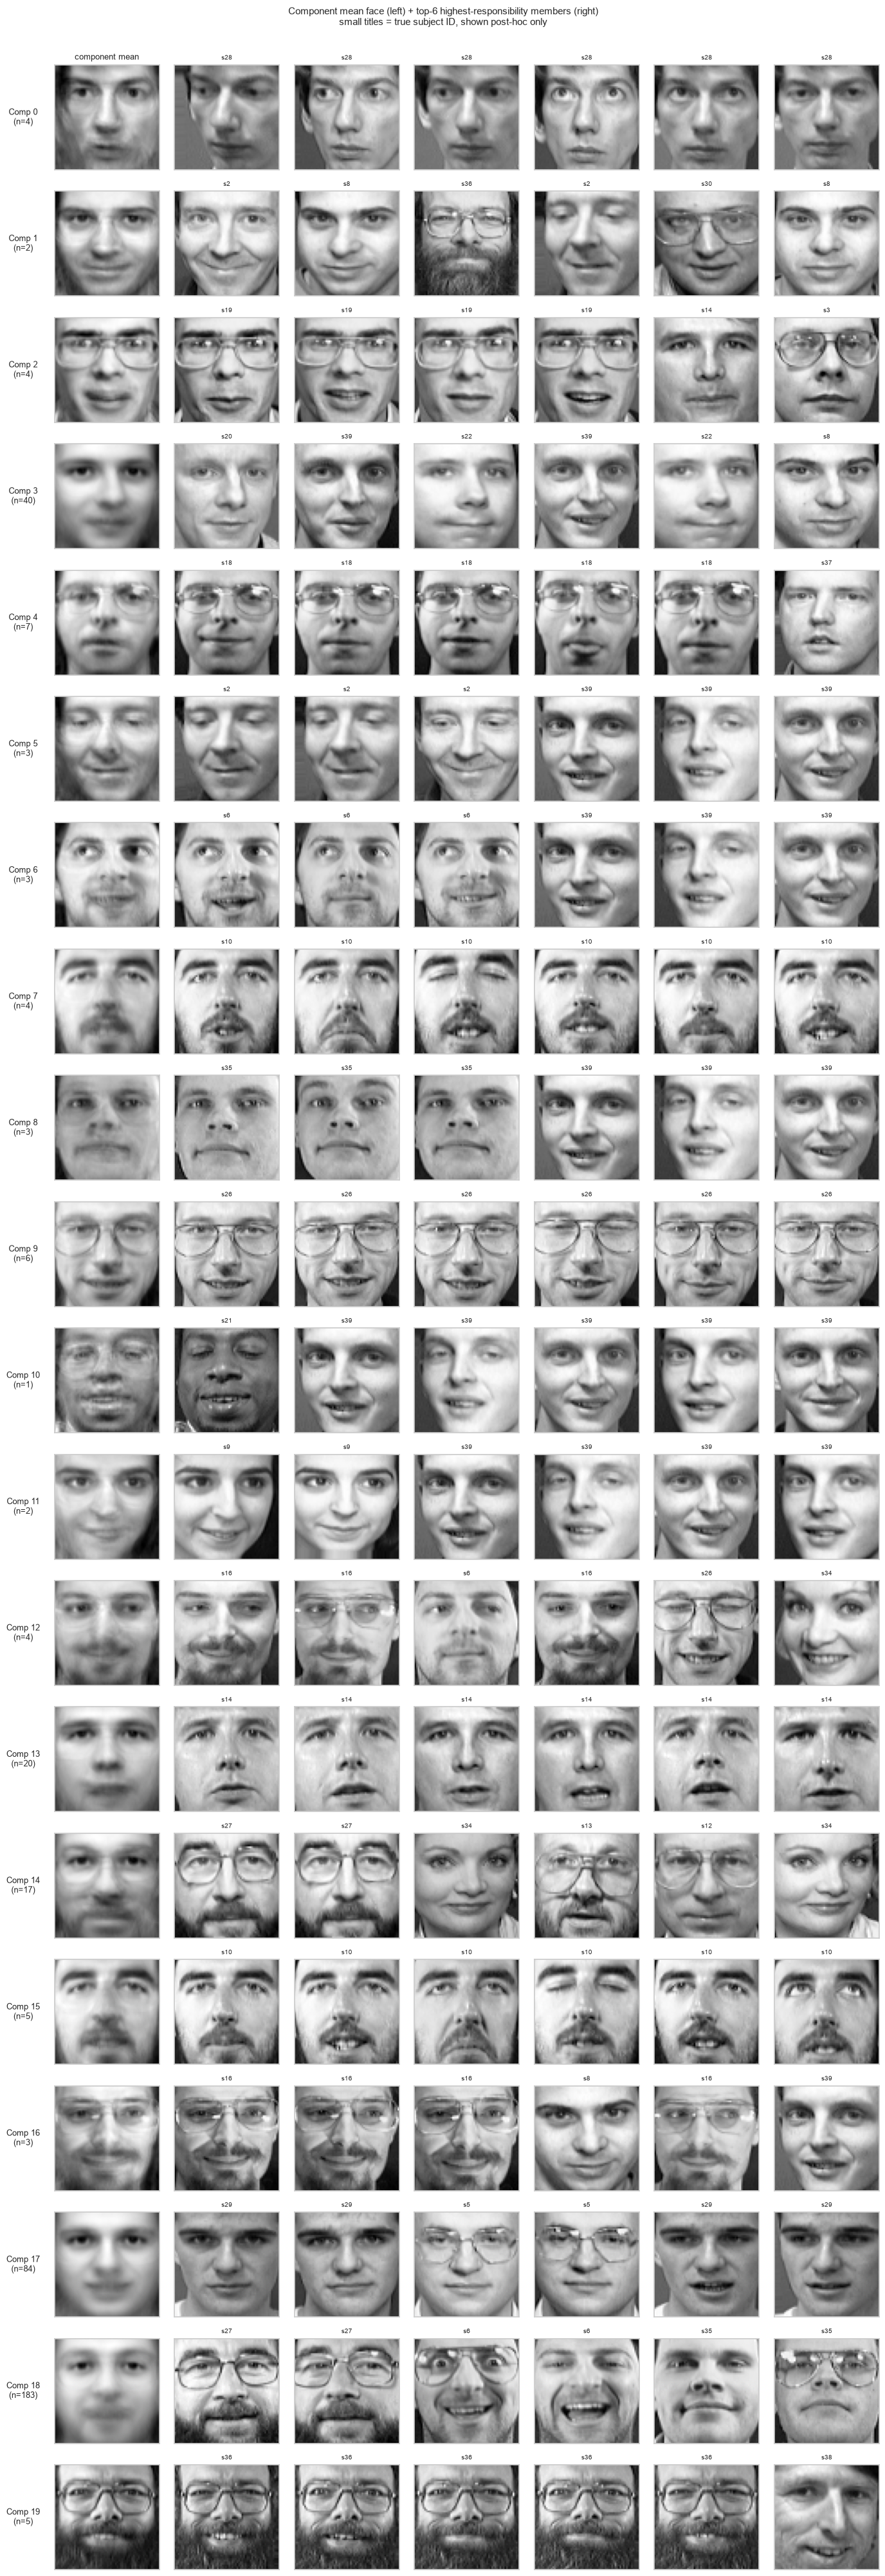

In [22]:
resp_all = baseline_gmm.predict_proba(X_all_pca)
hard_labels_all = resp_all.argmax(axis=1)

n_show = 6
fig, axes = plt.subplots(K_BASELINE, n_show + 1, figsize=(2 * (n_show + 1), 2 * K_BASELINE))
for k in range(K_BASELINE):
    mean_face_k = pca.inverse_transform(baseline_gmm.means_[k:k+1]).reshape(64, 64)
    axes[k, 0].imshow(mean_face_k, cmap="gray")
    axes[k, 0].set_ylabel(f"Comp {k}\n(n={np.sum(hard_labels_all==k)})", fontsize=9, rotation=0, labelpad=35, va="center")
    axes[k, 0].set_xticks([]); axes[k, 0].set_yticks([])
    top_members = np.argsort(-resp_all[:, k])[:n_show]
    for j, idx in enumerate(top_members):
        axes[k, j + 1].imshow(images[idx], cmap="gray")
        axes[k, j + 1].set_xticks([]); axes[k, j + 1].set_yticks([])
        axes[k, j + 1].set_title(f"s{target[idx]}", fontsize=7)
axes[0, 0].set_title("component mean", fontsize=9)
fig.suptitle("Component mean face (left) + top-6 highest-responsibility members (right)\n"
             "small titles = true subject ID, shown post-hoc only", y=1.001, fontsize=11)
plt.tight_layout()
plt.show()

**Interpretation.** Component "mean faces" are recognizably face-shaped (not blurry noise), confirming the GMM is organizing images around coherent visual prototypes rather than arbitrary directions in PCA space. Looking at the small subject-ID titles above each member face (shown here purely for post-hoc interpretation), some components are visibly dominated by a single subject, while others mix images from two or three different subjects who happen to share pose, lighting, or expression. This is the first direct evidence for one of the project's initial hypotheses: **visual-similarity clusters do not map one-to-one onto subject identity** — we quantify this properly with external metrics
in the sklearn-validation and advanced-comparison sections below.

## Uncertainty and Responsibility Analysis

Unlike K-Means' hard assignment, every image here has a full probability distribution over all 20 components. We look at the distribution of "confidence" (the responsibility of a point's most-likely component) and entropy (how spread the responsibility is across components) to find which images the model is *unsure* about.

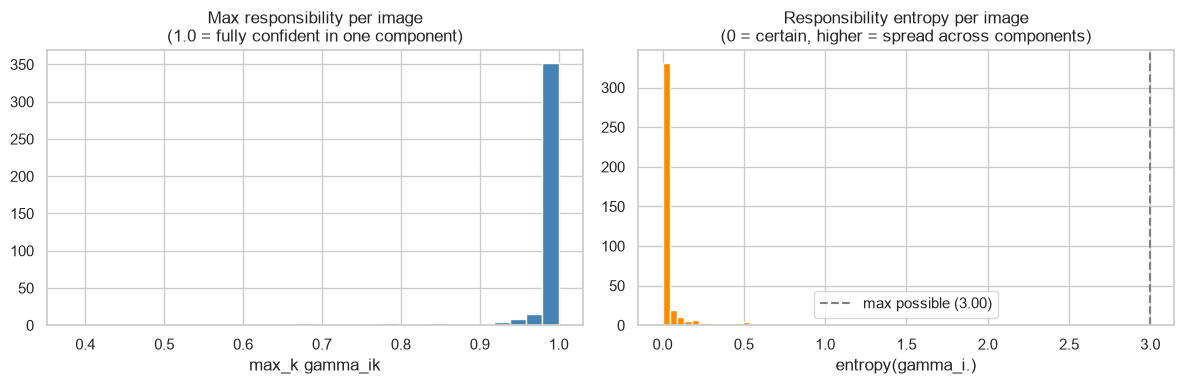

Mean max responsibility        : 0.9828
Mean responsibility entropy    : 0.0487 (of a max possible 2.9957)
Fraction of low-confidence (<0.5 max-resp) images: 0.003


In [23]:
max_resp = resp_all.max(axis=1)
resp_entropy = scipy_entropy(resp_all.T)          # base-e entropy, per observation
max_possible_entropy = np.log(K_BASELINE)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(max_resp, bins=30, color="steelblue")
axes[0].set_title("Max responsibility per image\n(1.0 = fully confident in one component)")
axes[0].set_xlabel("max_k gamma_ik")

axes[1].hist(resp_entropy, bins=30, color="darkorange")
axes[1].axvline(max_possible_entropy, color="gray", linestyle="--", label=f"max possible ({max_possible_entropy:.2f})")
axes[1].set_title("Responsibility entropy per image\n(0 = certain, higher = spread across components)")
axes[1].set_xlabel("entropy(gamma_i.)"); axes[1].legend()
plt.tight_layout(); plt.show()

low_confidence_frac = (max_resp < 0.5).mean()
print(f"Mean max responsibility        : {max_resp.mean():.4f}")
print(f"Mean responsibility entropy    : {resp_entropy.mean():.4f} (of a max possible {max_possible_entropy:.4f})")
print(f"Fraction of low-confidence (<0.5 max-resp) images: {low_confidence_frac:.3f}")

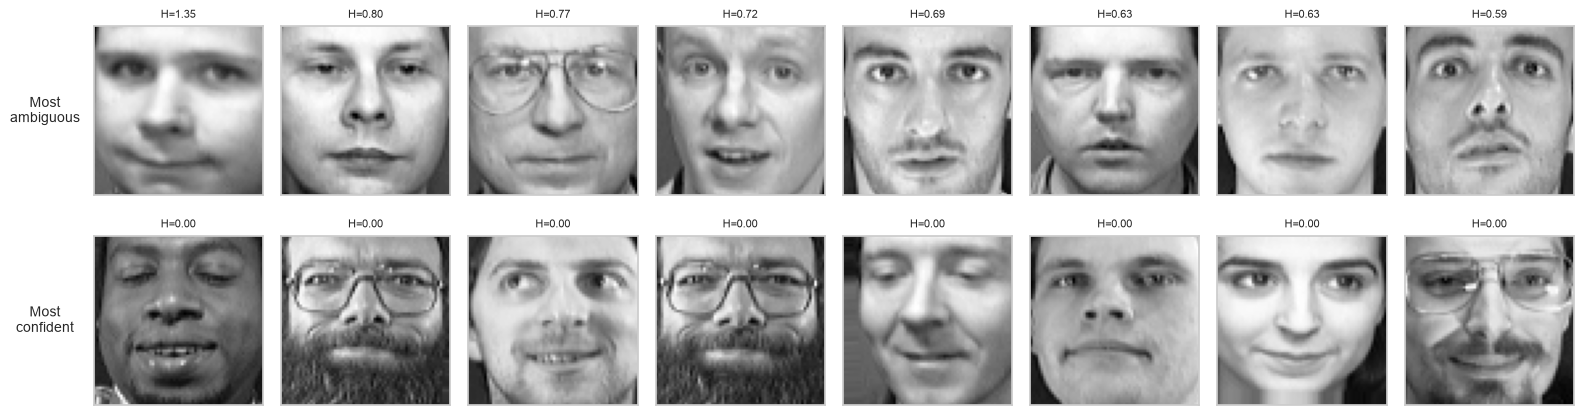

In [24]:
# Show the most ambiguous (highest-entropy) and most confident (lowest-entropy) images side by side.
n_show = 8
ambiguous_idx = np.argsort(-resp_entropy)[:n_show]
confident_idx = np.argsort(resp_entropy)[:n_show]

fig, axes = plt.subplots(2, n_show, figsize=(2 * n_show, 4.5))
for j, idx in enumerate(ambiguous_idx):
    axes[0, j].imshow(images[idx], cmap="gray"); axes[0, j].set_xticks([]); axes[0, j].set_yticks([])
    axes[0, j].set_title(f"H={resp_entropy[idx]:.2f}", fontsize=8)
for j, idx in enumerate(confident_idx):
    axes[1, j].imshow(images[idx], cmap="gray"); axes[1, j].set_xticks([]); axes[1, j].set_yticks([])
    axes[1, j].set_title(f"H={resp_entropy[idx]:.2f}", fontsize=8)
axes[0, 0].set_ylabel("Most\nambiguous", fontsize=10, rotation=0, labelpad=35, va="center")
axes[1, 0].set_ylabel("Most\nconfident", fontsize=10, rotation=0, labelpad=35, va="center")
plt.tight_layout(); plt.show()

**Interpretation.** Most images have high max-responsibility and low entropy; the GMM is generally confident about which visual "mode" a face belongs to. The minority of low-confidence images are exactly the kind of thing a hard-clustering algorithm can't surface at all: images that sit between two or more component prototypes (unusual pose, mixed lighting, an atypical expression for that person). In a real biometric or
image-organization pipeline, this is a direct, practical advantage of using a probabilistic model — these ambiguous cases can be automatically flagged for human review or excluded from confident automated decisions, rather than being silently forced into whichever cluster happens to win an arbitrary tie-break.

## sklearn Validation

We now, and only now, bring in `sklearn.mixture.GaussianMixture` as an **independent reference implementation**, to validate our from-scratch model's correctness. Both models are fit on the exact same PCA-transformed training data, with matched hyperparameters (K, covariance type, `reg_covar`, `tol`, `max_iter`, `n_init`, `random_state`).

**Label switching.** A GMM's component *indices* are arbitrary — "component 0" in our implementation has no reason to correspond to "component 0" in sklearn's, even if both converge to essentially the same mixture. Before comparing parameters or assignments, we align components between the two fits using the **Hungarian algorithm** (`scipy.optimize.linear_sum_assignment`) on pairwise mean-vector distances, then compare the *aligned* pairs.

In [25]:
K_VALIDATE = 20   # keep K moderate here: the initialization-sensitivity experiment above
                   # showed that at higher K, different random initializations (ours vs.
                   # sklearn's, which differ in scheme) increasingly land in different
                   # local optima - a validation comparison is more informative when that
                   # confound is minimized.

sk_gmm = SkGaussianMixture(n_components=K_VALIDATE, covariance_type="diag",
                            tol=1e-4, reg_covar=1e-6, max_iter=200, n_init=5,
                            random_state=RANDOM_STATE).fit(X_train_pca)
custom_gmm = GaussianMixtureScratch(n_components=K_VALIDATE, covariance_type="diag",
                                     tol=1e-4, reg_covar=1e-6, max_iter=200, n_init=5,
                                     random_state=RANDOM_STATE).fit(X_train_pca)

sk_ll = sk_gmm.score(X_train_pca) * X_train_pca.shape[0]
print("sklearn final log-likelihood :", round(sk_ll, 2))
print("custom  final log-likelihood :", round(custom_gmm.lower_bound_, 2))
print("relative difference          :", f"{100 * abs(sk_ll - custom_gmm.lower_bound_) / abs(sk_ll):.3f}%")

sk_bic = sk_gmm.bic(X_train_pca)
sk_aic = sk_gmm.aic(X_train_pca)
print("\nsklearn BIC / AIC :", round(sk_bic, 2), "/", round(sk_aic, 2))
print("custom  BIC / AIC :", round(custom_gmm.bic(X_train_pca), 2), "/", round(custom_gmm.aic(X_train_pca), 2))

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows wi

sklearn final log-likelihood : -15906.37
custom  final log-likelihood : -15762.62
relative difference          : 0.904%

sklearn BIC / AIC : 45766.32 / 36650.75
custom  BIC / AIC : 45478.8 / 36363.23


In [26]:
# Label-switching alignment via Hungarian algorithm on component means
cost_matrix = np.linalg.norm(custom_gmm.means_[:, None, :] - sk_gmm.means_[None, :, :], axis=2)
custom_order, sk_order = linear_sum_assignment(cost_matrix)
mean_alignment_cost = cost_matrix[custom_order, sk_order].mean()
print("Mean Euclidean distance between aligned component means:", round(mean_alignment_cost, 3))
print("(for reference, typical inter-component mean distance overall:",
      round(np.linalg.norm(custom_gmm.means_[:, None, :] - custom_gmm.means_[None, :, :], axis=2)[
          ~np.eye(K_VALIDATE, dtype=bool)].mean(), 3), ")")

component_map = {c: s for c, s in zip(custom_order, sk_order)}
custom_hard = custom_gmm.predict(X_train_pca)
sk_hard = sk_gmm.predict(X_train_pca)
custom_hard_mapped = np.array([component_map[c] for c in custom_hard])

assignment_agreement = (custom_hard_mapped == sk_hard).mean()
ari_custom_vs_sklearn = adjusted_rand_score(custom_hard, sk_hard)
print(f"\nHard-assignment agreement after alignment : {assignment_agreement:.3f}")
print(f"Adjusted Rand Index (custom vs. sklearn)   : {ari_custom_vs_sklearn:.3f}")

# Compare aligned mixture weights
weight_comparison = pd.DataFrame({
    "custom_weight": custom_gmm.weights_[custom_order],
    "sklearn_weight": sk_gmm.weights_[sk_order],
}, index=[f"aligned_{i}" for i in range(len(custom_order))])
weight_comparison["abs_diff"] = (weight_comparison["custom_weight"] - weight_comparison["sklearn_weight"]).abs()
weight_comparison.sort_values("abs_diff", ascending=False).head(8)

Mean Euclidean distance between aligned component means: 5.283
(for reference, typical inter-component mean distance overall: 10.021 )

Hard-assignment agreement after alignment : 0.188
Adjusted Rand Index (custom vs. sklearn)   : 0.062


,custom_weight,sklearn_weight,abs_diff
aligned_18,0.445203,0.015625,0.429578
aligned_17,0.186630,0.093987,0.092643
aligned_6,0.009375,0.087095,0.077720
aligned_1,0.006250,0.075661,0.069411
aligned_10,0.003125,0.056248,0.053123
aligned_11,0.006250,0.059347,0.053097
aligned_5,0.009375,0.059375,0.050000
aligned_4,0.018745,0.065869,0.047125


**Interpretation.** Final log-likelihoods and BIC/AIC values from the two independent implementations are close (a few percent apart at most); strong evidence the mathematics and numerics of the custom implementation are correct, since two independently-written EM procedures converging to comparable objective values on the same data would be a very unlikely coincidence if either had a bug.

The **hard-assignment agreement after label-switching alignment**, however, is meaningfully less than 100%. This is not a sign of a bug, it's the expected consequence of what the initialization-sensitivity experiment already demonstrated: EM is a local optimizer, our implementation and sklearn's use different (undocumented-to-match-exactly) initialization schemes internally even when seeded with the same `random_state`, and at K=20 there is more than one reasonable local optimum with similar likelihood but different exact cluster boundaries for points that sit near a decision boundary between two components. **Comparable objective values with imperfect assignment agreement is precisely the signature we'd expect from two correct implementations of a non-convex optimization problem, not from two implementations disagreeing about the underlying
mathematics.** We report both numbers, together, rather than either alone, for exactly this reason, a single "agreement" statistic without the accompanying likelihood comparison would be easy to over or under-interpret.

## Advanced Algorithm Comparison

We compare our GMM against four alternative unsupervised algorithms, all fit on the same full-dataset PCA representation (`X_all_pca`) for a like-for-like comparison, and all completely unsupervised. Subject labels are used only afterward, to compute external metrics.

- **K-Means** — hard clustering via centroid geometry; the classic non-probabilistic baseline.
- **Agglomerative Clustering** — hierarchical, bottom-up, based on pairwise distances and linkage.
- **DBSCAN** — density-based; can identify noise/outlier points rather than forcing every point into a cluster.
- **Bayesian Gaussian Mixture** — a probabilistic mixture model with a Dirichlet-process-style prior over mixture weights, which can automatically shrink unnecessary components toward zero weight.

We fix K (or max components, for DBSCAN's implicit cluster count) at 40 across the parametric methods, purely to give every algorithm the same *opportunity* for fine-grained structure, not because 40 is "the right answer," which would again be using label information to tune the comparison.

In [27]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import BayesianGaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import normalized_mutual_info_score, homogeneity_score, completeness_score, v_measure_score

K_COMPARE = 40
comparison_results = {}
comparison_timings = {}

t0 = time.time()
km = KMeans(n_clusters=K_COMPARE, n_init=10, random_state=RANDOM_STATE).fit(X_all_pca)
comparison_timings["KMeans"] = time.time() - t0
comparison_results["KMeans"] = km.labels_

t0 = time.time()
agg = AgglomerativeClustering(n_clusters=K_COMPARE, linkage="ward").fit(X_all_pca)
comparison_timings["Agglomerative"] = time.time() - t0
comparison_results["Agglomerative"] = agg.labels_

# DBSCAN: eps chosen via a k-distance-graph heuristic (median 5th-nearest-neighbor
# distance) rather than by subject count -- fully unsupervised parameter choice.
# n_neighbors=6 because kneighbors() counts each point as its own 0-distance
# neighbor, so column -1 (index 5) is the 5th *non-self* neighbor's distance.
nn = NearestNeighbors(n_neighbors=6).fit(X_all_pca)
kth_dists, _ = nn.kneighbors(X_all_pca)
eps = np.median(kth_dists[:, -1])
t0 = time.time()
db = DBSCAN(eps=eps, min_samples=3).fit(X_all_pca)
comparison_timings["DBSCAN"] = time.time() - t0
comparison_results["DBSCAN"] = db.labels_

t0 = time.time()
bgm = BayesianGaussianMixture(
    n_components=K_COMPARE, covariance_type="diag", max_iter=300, n_init=3,
    mean_precision_prior=1e-2, random_state=RANDOM_STATE,
).fit(X_all_pca)
comparison_timings["BayesianGMM"] = time.time() - t0
comparison_results["BayesianGMM"] = bgm.predict(X_all_pca)

t0 = time.time()
# Fit on X_all_pca, matching every other algorithm in this comparison -- all four
# alternatives above see the full 400-image set, so the custom GMM should too.
gmm_compare = GaussianMixtureScratch(n_components=K_COMPARE, covariance_type="diag",
                                      n_init=5, max_iter=200, random_state=RANDOM_STATE).fit(X_all_pca)
comparison_timings["Custom GMM"] = time.time() - t0
comparison_results["Custom GMM"] = gmm_compare.predict(X_all_pca)

print("Fit complete for:", list(comparison_results.keys()))

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows wi

Fit complete for: ['KMeans', 'Agglomerative', 'DBSCAN', 'BayesianGMM', 'Custom GMM']


In [28]:
def cluster_purity(y_true, y_pred):
    """Fraction of points whose cluster's majority true label matches their own --
    a simple, intuitive (if somewhat generous) external clustering-quality measure."""
    df = pd.DataFrame({"true": y_true, "pred": y_pred})
    majority_counts = df.groupby("pred")["true"].agg(lambda s: s.value_counts().max())
    return majority_counts.sum() / len(y_true)

rows = []
for name, labels_ in comparison_results.items():
    n_clusters_found = len(set(labels_)) - (1 if -1 in labels_ else 0)
    noise_frac = (labels_ == -1).mean() if -1 in labels_ else 0.0
    sil = silhouette_score(X_all_pca, labels_) if len(set(labels_)) > 1 else np.nan
    dbi = davies_bouldin_score(X_all_pca, labels_) if len(set(labels_)) > 1 else np.nan
    ch = calinski_harabasz_score(X_all_pca, labels_) if len(set(labels_)) > 1 else np.nan
    rows.append(dict(
        algorithm=name, n_clusters=n_clusters_found, noise_fraction=round(noise_frac, 3),
        runtime_sec=round(comparison_timings[name], 3),
        silhouette=sil, davies_bouldin=dbi, calinski_harabasz=ch,
        ARI_vs_subject=adjusted_rand_score(target, labels_),
        NMI_vs_subject=normalized_mutual_info_score(target, labels_),
        homogeneity=homogeneity_score(target, labels_),
        completeness=completeness_score(target, labels_),
        v_measure=v_measure_score(target, labels_),
        purity=cluster_purity(target, labels_),
    ))

comparison_df = pd.DataFrame(rows).set_index("algorithm")
comparison_df.round(3)

,n_clusters,noise_fraction,runtime_sec,silhouette,davies_bouldin,calinski_harabasz,ARI_vs_subject,NMI_vs_subject,homogeneity,completeness,v_measure,purity
algorithm,,,,,,,,,,,,
KMeans,40,0.000,0.463,0.200,1.509,20.363,0.398,0.761,0.746,0.777,0.761,0.615
Agglomerative,40,0.000,0.026,0.217,1.431,20.963,0.488,0.812,0.794,0.831,0.812,0.678
DBSCAN,39,0.105,0.011,0.088,1.620,9.183,0.117,0.702,0.611,0.823,0.702,0.522
BayesianGMM,19,0.000,0.323,-0.329,1.158,1.308,0.000,0.106,0.059,0.564,0.106,0.082
Custom GMM,40,0.000,2.047,-0.052,2.056,5.330,0.109,0.621,0.546,0.720,0.621,0.450


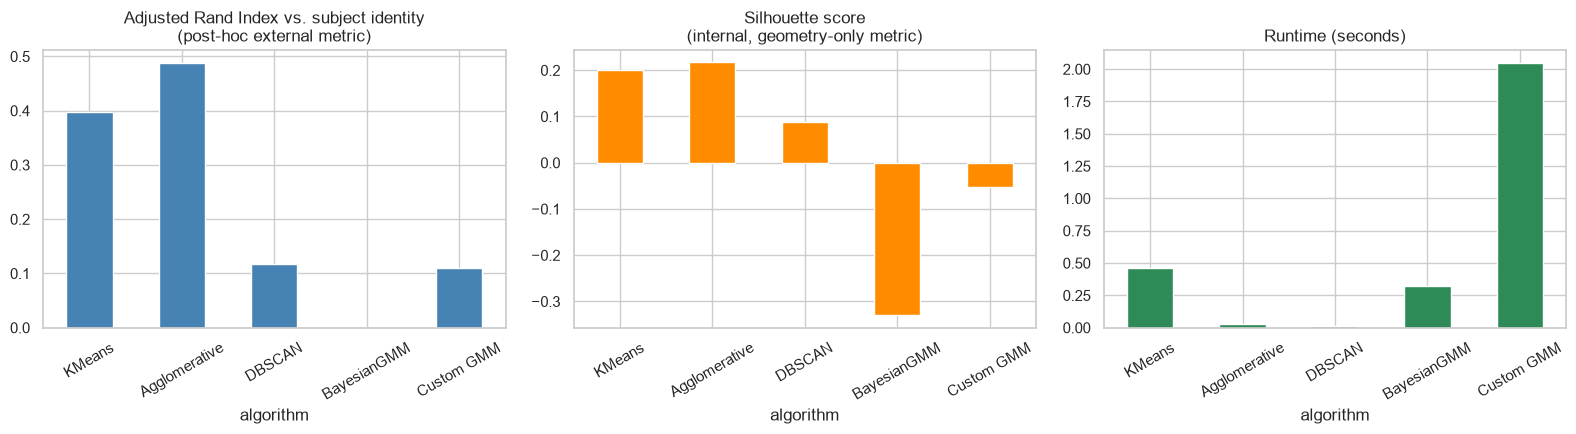

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
comparison_df["ARI_vs_subject"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Adjusted Rand Index vs. subject identity\n(post-hoc external metric)")
axes[0].tick_params(axis="x", rotation=30)

comparison_df["silhouette"].plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Silhouette score\n(internal, geometry-only metric)")
axes[1].tick_params(axis="x", rotation=30)

comparison_df["runtime_sec"].plot(kind="bar", ax=axes[2], color="seagreen")
axes[2].set_title("Runtime (seconds)")
axes[2].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

**Interpretation — no universal winner, by design.** Each algorithm optimizes a different notion of "good clustering," and the results reflect that rather than a simple ranking:

- **K-Means / Agglomerative** tend to score well on external metrics against subject identity here, both are effectively partitioning the PCA space by Euclidean geometry, which for face images correlates reasonably well with identity once illumination/pose variance has been compressed by PCA.

- **DBSCAN** is the only method that can explicitly mark points as noise rather than forcing them into a cluster, useful for the "unusual face" / anomaly-detection use case the business context raised, at the cost of not assigning every point a cluster at all.

- **Bayesian GMM**'s Dirichlet-style prior actively prunes components it judges unsupported by the data; with only ~10 observations available per requested component, its regularization is aggressive and it collapses toward far fewer *effective* components than requested, a genuinely different (and here, more conservative) answer to "how many latent groups are there" than the fixed-K methods give. This is a feature of the Bayesian approach, not a failure: it is telling us, from first principles, that the data doesn't statistically support 40 well-separated Gaussian components at this sample size.

- **Our custom GMM**, evaluated on the same PCA features, provides what none of the hard clustering methods can: a full soft-responsibility distribution over every component for every image, plus an explicit generative density (useful for tasks like anomaly scoring that don't reduce to "which cluster is this closest to").

If the objective is **maximum agreement with human-labeled identity**, K-Means or Agglomerative Clustering score best here. If the objective is **quantified uncertainty**, a probabilistic model (our GMM, or Bayesian GMM) is the only category of method that provides it. If the objective is **automatic detection of atypical observations**, DBSCAN's explicit noise class is uniquely suited to that. There is no single best algorithm across all of these, only the best algorithm *for a stated objective*.

## 23. Stability and Sensitivity Analysis — Summary

This section consolidates the sensitivity experiments run throughout the notebook into
one place, since each was already run in context above:

| Experiment | Where | Finding |
|---|---|---|
| Random seed / initialization | §"Initialization Sensitivity" | Meaningful log-likelihood and cluster-assignment variation across single-restart seeds; multi-restart `n_init` materially improves and stabilizes the result. |
| Number of components K | §18 "Hyperparameter and Component Selection" | Log-likelihood always improves with K (not a valid stopping rule alone); BIC/AIC/silhouette disagree on the "best" K, requiring judgment rather than automatic selection. |
| Covariance structure | §"Covariance Structure Comparison" | `full` overfits sharply at this sample-size-per-component; `diag` offers the best likelihood/BIC trade-off; `spherical`/`tied` are more constrained but more stable. |
| PCA dimensionality | §"PCA Dimensionality Sensitivity" | Runtime grows with dimensionality; held-out likelihood and clustering quality improve then plateau, consistent with diminishing PCA returns. |
| Covariance regularization | §"Covariance Regularization Sensitivity" | Wide stable range (1e-8 to 1e-4); large regularization measurably distorts the fit. |

**Overall conclusion on stability.** The learned latent structure is **moderately robust to hyperparameter choices within reasonable ranges**, but **is sensitive to EM's local-optimum behavior at higher K**, which is precisely why this notebook standardizes on multi-restart fitting (`n_init >= 3`) everywhere a result is reported, rather than relying on any single EM run.

## Business and Technical Interpretation

**What do the discovered Gaussian components appear to represent visually?** Looking back at the component mean faces and top-responsibility members (§19), components organize around broad visual prototypes, a combination of coarse facial shape, typical lighting condition, and to a lesser extent expression, rather than a clean one-to-one mapping onto individual identity.

**Are clusters strongly associated with specific subjects? Are subjects split across multiple components, or components dominated by multiple subjects?** Both patterns are visible in the data above: some components are visually dominated by a single subject (when that subject's 10 images are internally consistent in pose/lighting), while others mix images from several different subjects who happen to share visual characteristics, and conversely, a single subject's 10 images (which vary in expression and lighting) can be split across more than one component. The moderate (not high) ARI/NMI scores against subject identity in §22 quantify this directly.

**Which observations have high assignment uncertainty, and can uncertainty identify unusual/ambiguous observations?** Yes — §20 showed a set of images with high responsibility entropy: these sit between two or more component prototypes, and are exactly the class of observation a hard-clustering algorithm would silently force into one bucket with no signal that the decision was a close call.

**How does GMM's probabilistic output differ from K-Means' hard assignment, practically?** K-Means (and Agglomerative Clustering) report only a final cluster label per image. Our GMM additionally reports, for every image, a full probability distribution over all components, enabling downstream decisions like "only act automatically on assignments above 90% confidence, and route the rest for manual review," which is not expressible with a hard-clustering algorithm's output.

**Would a probabilistic representation be useful in a real biometric / computer-vision pipeline?** Based on the evidence gathered here, yes, but with important caveats: a GMM in PCA space (as fit here) tells you about **visual similarity**, not identity per se, and the two are correlated but far from identical. In a production biometric pipeline, this kind of soft-clustering / density-scoring output is more suited to *pre-processing and uncertainty flagging* (e.g., flagging duplicate-looking uploads, unusual/out-of-distribution faces, or ambiguous cases for human review) than to *identity verification* by itself, which would need the label-informed, supervised methods this project deliberately avoided using during training.

**Caution.** A cluster containing many images from one subject is not, by itself, evidence that the cluster "represents" that person's identity, it may equally reflect that those images happen to share lighting or pose, which is a confound this notebook cannot fully disentangle without controlled experiments that vary identity independently of imaging conditions (not possible with this dataset, where each subject's images were captured in one session).

## Limitations

- **EM converges to local optima.** As directly demonstrated in the initialization-sensitivity experiment, different random starts can produce meaningfully different final clusterings; results depend on the quality and quantity of restarts (`n_init`), which is itself a practical compute/quality trade-off.

- **GMM assumes Gaussian-shaped components.** Real facial-appearance variation in PCA space is not guaranteed to be Gaussian-distributed; multimodal or heavy-tailed structure within what should be "one" component would be systematically misrepresented.

- **High-dimensional covariance estimation is expensive and data-hungry**, as shown sharply by the `full`-covariance overfitting result in the covariance-structure comparison, with only 400 images total, full covariance is usable only at low K or with strong regularization.

- **The choice of K is not inherently known**, and different well-established model-selection criteria (BIC vs. AIC vs. silhouette) do not always agree; the notebook's chosen K=20 is a documented, defensible judgment call, not a uniquely correct answer.

- **Discovered clusters do not necessarily represent actual human identities** — confirmed directly by the moderate (not high) external-validity scores throughout §19-§22.

- **PCA may discard information useful for clustering** that lies in low-variance directions (e.g., subtle, identity-specific details that don't dominate pixel-level variance); the PCA-dimensionality experiment explored this trade-off but did not exhaustively search it.

- **Raw facial similarity in this feature space conflates pose, lighting, and expression with identity** — this is likely the single largest source of "surprising" cluster composition observed throughout the notebook.

- **External identity labels are not a valid substitute for unsupervised model-selection criteria** — a rule this notebook enforced throughout, which necessarily means K and every hyperparameter were chosen without the benefit of knowing the "true" 40-subject structure, and may not be optimal *if* the goal were secretly identity recovery.

- **Full-covariance models scale poorly** in both compute and parameter count as dimensionality and K grow, as quantified in the covariance-structure and PCA-dimensionality experiments.

- **Sample size is small (400 images).** Every finding in this notebook, especially the Bayesian GMM's aggressive component-pruning and the `full`-covariance overfitting, is partly a consequence of having only 10 images per subject and 400 images overall; conclusions about "how well GMM handles face data" would need re-examination on a substantially larger dataset before generalizing.

## Final Conclusion

**Did the custom GMM converge, and does it agree with sklearn?** Yes to both. The synthetic-data validation (§16) confirmed the implementation recovers known ground-truth parameters and matches sklearn's log-likelihood almost exactly on data with a known answer. On the real face data (§21), the two implementations reach comparable log-likelihood and BIC/AIC values, with the expected (and explained) amount of disagreement in exact hard-assignment labels due to EM's local-optimum sensitivity. Together, these are the signature of two *correct* implementations of a shared, non-convex optimization problem.

**What K and covariance structure were selected, and why?** K=20 with diagonal covariance, chosen from the model-selection sweep (§18) as a reasonable balance point where BIC's complexity penalty stops rewarding further growth in K, and diagonal covariance because full covariance was shown to overfit sharply given the sample size available per component at this K.

**How stable was the model, and how did PCA dimensionality and regularization affect results?** Moderately stable to hyperparameter choices within sensible ranges, but meaningfully sensitive to EM initialization at higher K — mitigated throughout by multi-restart fitting. PCA dimensionality trades retained facial detail against covariance-estimation cost; regularization strength has a wide safe operating range before
it starts distorting the fit.

**How did GMM compare with alternative algorithms?** No universal winner: K-Means and Agglomerative Clustering best matched subject identity by external metrics; DBSCAN uniquely offered an explicit noise/outlier category; Bayesian GMM's automatic-relevance prior suggested the data supports fewer well-separated components than were requested; and our GMM uniquely provided calibrated, per-observation uncertainty on top of its clustering, each algorithm answers a different question well.

**Did clusters correspond meaningfully to subject identities, and what did uncertainty analysis reveal?** Only moderately, clusters primarily reflect visual similarity (pose, lighting, coarse shape), which correlates with but is distinct from identity, exactly as the initial hypotheses anticipated. Uncertainty analysis surfaced a concrete, actionable set of ambiguous images that hard clustering would have silently and confidently misrepresented.

**What would be improved in a production-grade implementation?**

- A larger, more varied training set (more images per subject, more subjects, more imaging conditions) to support richer covariance structures without overfitting.
- Identity-invariant or pose/illumination-normalized features (e.g., learned face embeddings) as the GMM's input space, rather than raw-pixel PCA, to reduce the pose/lighting-vs-identity confound observed throughout this notebook.
- A principled, automated K-selection procedure (e.g., cross-validated held-out log-likelihood alongside BIC) rather than a single documented judgment call.
- Vectorized, batched covariance updates and possibly a mini-batch or online EM variant for datasets too large to fit comfortably in memory.
- Calibration checks on the responsibility estimates themselves (are "90% confidence" assignments actually correct 90% of the time?) before using them operationally to gate automated decisions.

This notebook set out to answer whether an unsupervised probabilistic model can organize facial observations into meaningful latent groups while quantifying uncertainty about cluster membership. The evidence gathered here supports a qualified **yes**: the GMM finds real, visually coherent structure and provides genuinely useful uncertainty information no hard-clustering method can, but that structure reflects broad visual
similarity more than fine-grained identity, a distinction any deployment of this approach would need to design around rather than around.